In [1]:
# ==========================================
# 🚀 COMPLETE SETUP CELL
# Har kernel restart ke baad SIRF YEH EK CELL chalayein
# Sab kuch dobara tayyar ho jayega
# ==========================================

# ==================== IMPORTS ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pickle
import os
import warnings
from datetime import datetime
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')

# ==================== STYLE ====================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# ==================== PATHS ====================
BASE_PATH = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
# Fallback path (agar __file__ na mile)
if not os.path.exists(BASE_PATH):
    BASE_PATH = r'D:\DA projects\Covid-19-portfolio'

DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed')
MODELS_PATH = os.path.join(BASE_PATH, 'models')
FIGURES_PATH = os.path.join(BASE_PATH, 'outputs', 'figures')

# Agar notebook se chal rahe hain (notebooks folder mein)
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join(BASE_PATH, '..', 'data', 'processed')
    MODELS_PATH = os.path.join(BASE_PATH, '..', 'models')
    FIGURES_PATH = os.path.join(BASE_PATH, '..', 'outputs', 'figures')

# Absolute safe paths (aap ki file system ke liye)
DATA_PATH = r'D:\DA projects\Covid-19-portfolio\data\processed'
MODELS_PATH = r'D:\DA projects\Covid-19-portfolio\models'
FIGURES_PATH = r'D:\DA projects\Covid-19-portfolio\outputs\figures'

# Folders ensure
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

print("Paths:")
print(f"  Data:    {DATA_PATH}")
print(f"  Models:  {MODELS_PATH}")
print(f"  Figures: {FIGURES_PATH}")

# ==================== LOAD DATA ====================
df = pd.read_csv(os.path.join(DATA_PATH, 'PK_COVID_19_cleaned.csv'))
df['Date'] = pd.to_datetime(df['Date'])

# ==================== DATA CLEANING ====================
df['Province'] = df['Province'].str.strip()
df['City'] = df['City'].str.strip()
df['Travel_history'] = df['Travel_history'].fillna('Unknown').str.strip()

# ==================== FEATURE ENGINEERING ====================
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b-%Y')
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.day_name()
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['Quarter'] = df['Date'].dt.quarter
df['Active'] = df['Cases'] - df['Deaths'] - df['Recovered']
df['CFR'] = np.where(df['Cases'] > 0, df['Deaths'] / df['Cases'] * 100, 0)
df['Recovery_Rate'] = np.where(df['Cases'] > 0, df['Recovered'] / df['Cases'] * 100, 0)
df['Is_Local'] = df['Travel_history'].str.contains('Local', na=False).astype(int)
df['Is_Tableeghi'] = df['Travel_history'].str.contains('Tableeghi', na=False).astype(int)

# ==================== AGGREGATED DATA ====================
# Daily summary
daily = df.groupby('Date').agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'}).reset_index()
daily['Active'] = daily['Cases'] - daily['Deaths'] - daily['Recovered']
daily['Cumulative_Cases'] = daily['Cases'].cumsum()
daily['Cumulative_Deaths'] = daily['Deaths'].cumsum()
daily['Cumulative_Recovered'] = daily['Recovered'].cumsum()
daily['Cumulative_Active'] = daily['Cumulative_Cases'] - daily['Cumulative_Deaths'] - daily['Cumulative_Recovered']
daily['CFR'] = (daily['Cumulative_Deaths'] / daily['Cumulative_Cases'] * 100).round(2)
daily['Recovery_Rate'] = (daily['Cumulative_Recovered'] / daily['Cumulative_Cases'] * 100).round(2)

# Province summary
province_summary = df.groupby('Province').agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'}).reset_index()
province_summary['Active'] = province_summary['Cases'] - province_summary['Deaths'] - province_summary['Recovered']
province_summary['CFR'] = (province_summary['Deaths'] / province_summary['Cases'] * 100).round(2)
province_summary['Recovery_Rate'] = (province_summary['Recovered'] / province_summary['Cases'] * 100).round(2)
province_summary = province_summary.sort_values('Cases', ascending=False).reset_index(drop=True)

# City summary
city_summary = df.groupby(['City', 'Province']).agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'}).reset_index()
city_summary = city_summary.sort_values('Cases', ascending=False).reset_index(drop=True)

# Travel history summary
travel_summary = df.groupby('Travel_history').agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum', 'Date': 'count'}).reset_index()
travel_summary = travel_summary.rename(columns={'Date': 'Records'})
travel_summary['Avg_Cases_per_Record'] = (travel_summary['Cases'] / travel_summary['Records']).round(2)
travel_summary = travel_summary.sort_values('Cases', ascending=False).reset_index(drop=True)

# Province × Month pivot
pivot_prov_time = df.pivot_table(values='Cases', index='Month_Name', columns='Province', aggfunc='sum', fill_value=0)
month_order = ['Feb-2020', 'Mar-2020', 'Apr-2020', 'May-2020', 'Jun-2020']
pivot_prov_time = pivot_prov_time.reindex([m for m in month_order if m in pivot_prov_time.index])

# ==================== ENCODING & FEATURES ====================
le = LabelEncoder()
df['Province_Encoded'] = le.fit_transform(df['Province'])

features = ['Deaths', 'Recovered', 'Is_Local', 'Is_Tableeghi', 'Month', 'DayOfWeek', 'Province_Encoded']
# Note: DayOfWeek ab string hai, is liye numeric banayein
df['DayOfWeek_Num'] = pd.to_datetime(df['Date']).dt.dayofweek
features = ['Deaths', 'Recovered', 'Is_Local', 'Is_Tableeghi', 'Month', 'DayOfWeek_Num', 'Province_Encoded']

X = df[features]
y = df['Cases']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==================== MODELS ====================
lr = LinearRegression()
lr.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

# ==================== SUMMARY ====================
print("\n" + "=" * 60)
print("✅ SETUP COMPLETE — SAB KUCH READY HAI!")
print("=" * 60)
print(f"📊 Data:              {df.shape}")
print(f"📅 Date range:        {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"🗺️  Provinces:         {df['Province'].nunique()}")
print(f"🏙️  Cities:            {df['City'].nunique()}")
print(f"🤖 Models trained:    LR, RF, GB")
print(f"📈 Daily summary:     {daily.shape}")
print(f"📈 Province summary:  {province_summary.shape}")
print(f"📈 City summary:      {city_summary.shape}")
print(f"📈 Travel summary:    {travel_summary.shape}")
print("=" * 60)
print("\n✅ Ab baqi cells dobara chala sakte hain!")

Paths:
  Data:    D:\DA projects\Covid-19-portfolio\data\processed
  Models:  D:\DA projects\Covid-19-portfolio\models
  Figures: D:\DA projects\Covid-19-portfolio\outputs\figures

✅ SETUP COMPLETE — SAB KUCH READY HAI!
📊 Data:              (2798, 21)
📅 Date range:        2020-02-26 to 2020-06-03
🗺️  Provinces:         8
🏙️  Cities:            125
🤖 Models trained:    LR, RF, GB
📈 Daily summary:     (91, 11)
📈 Province summary:  (8, 7)
📈 City summary:      (131, 5)
📈 Travel summary:    (15, 6)

✅ Ab baqi cells dobara chala sakte hain!


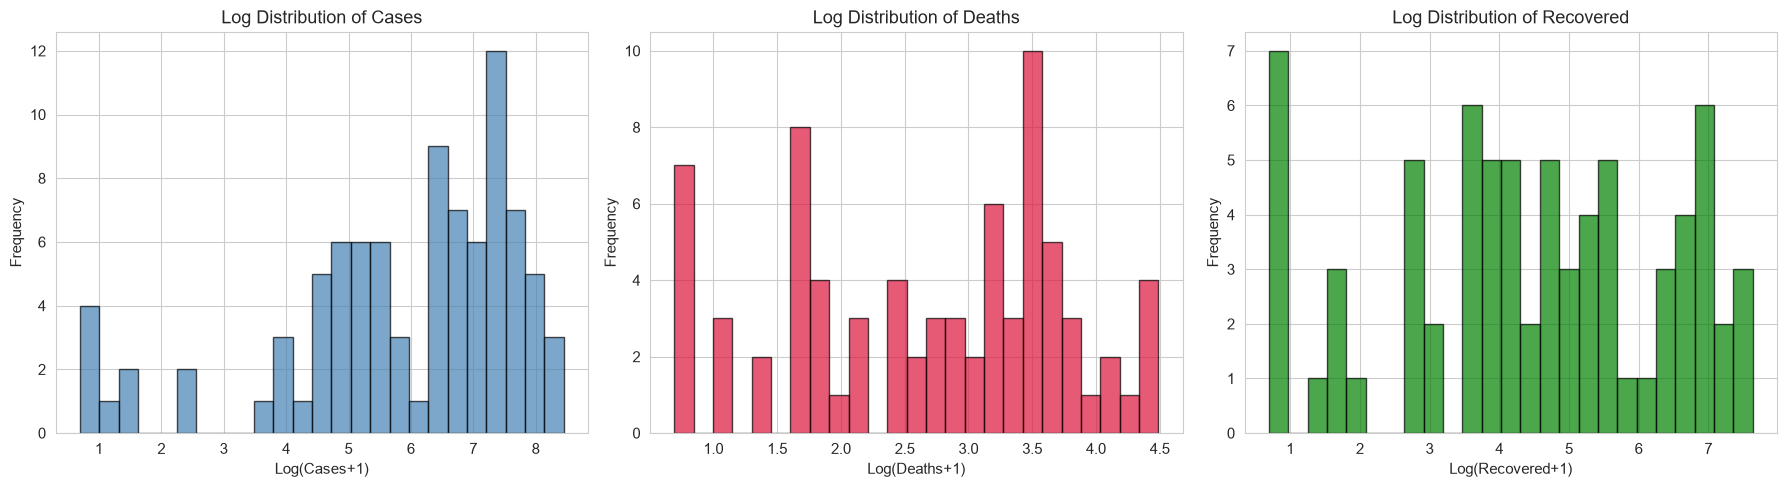

✅ 14_histogram_log.png


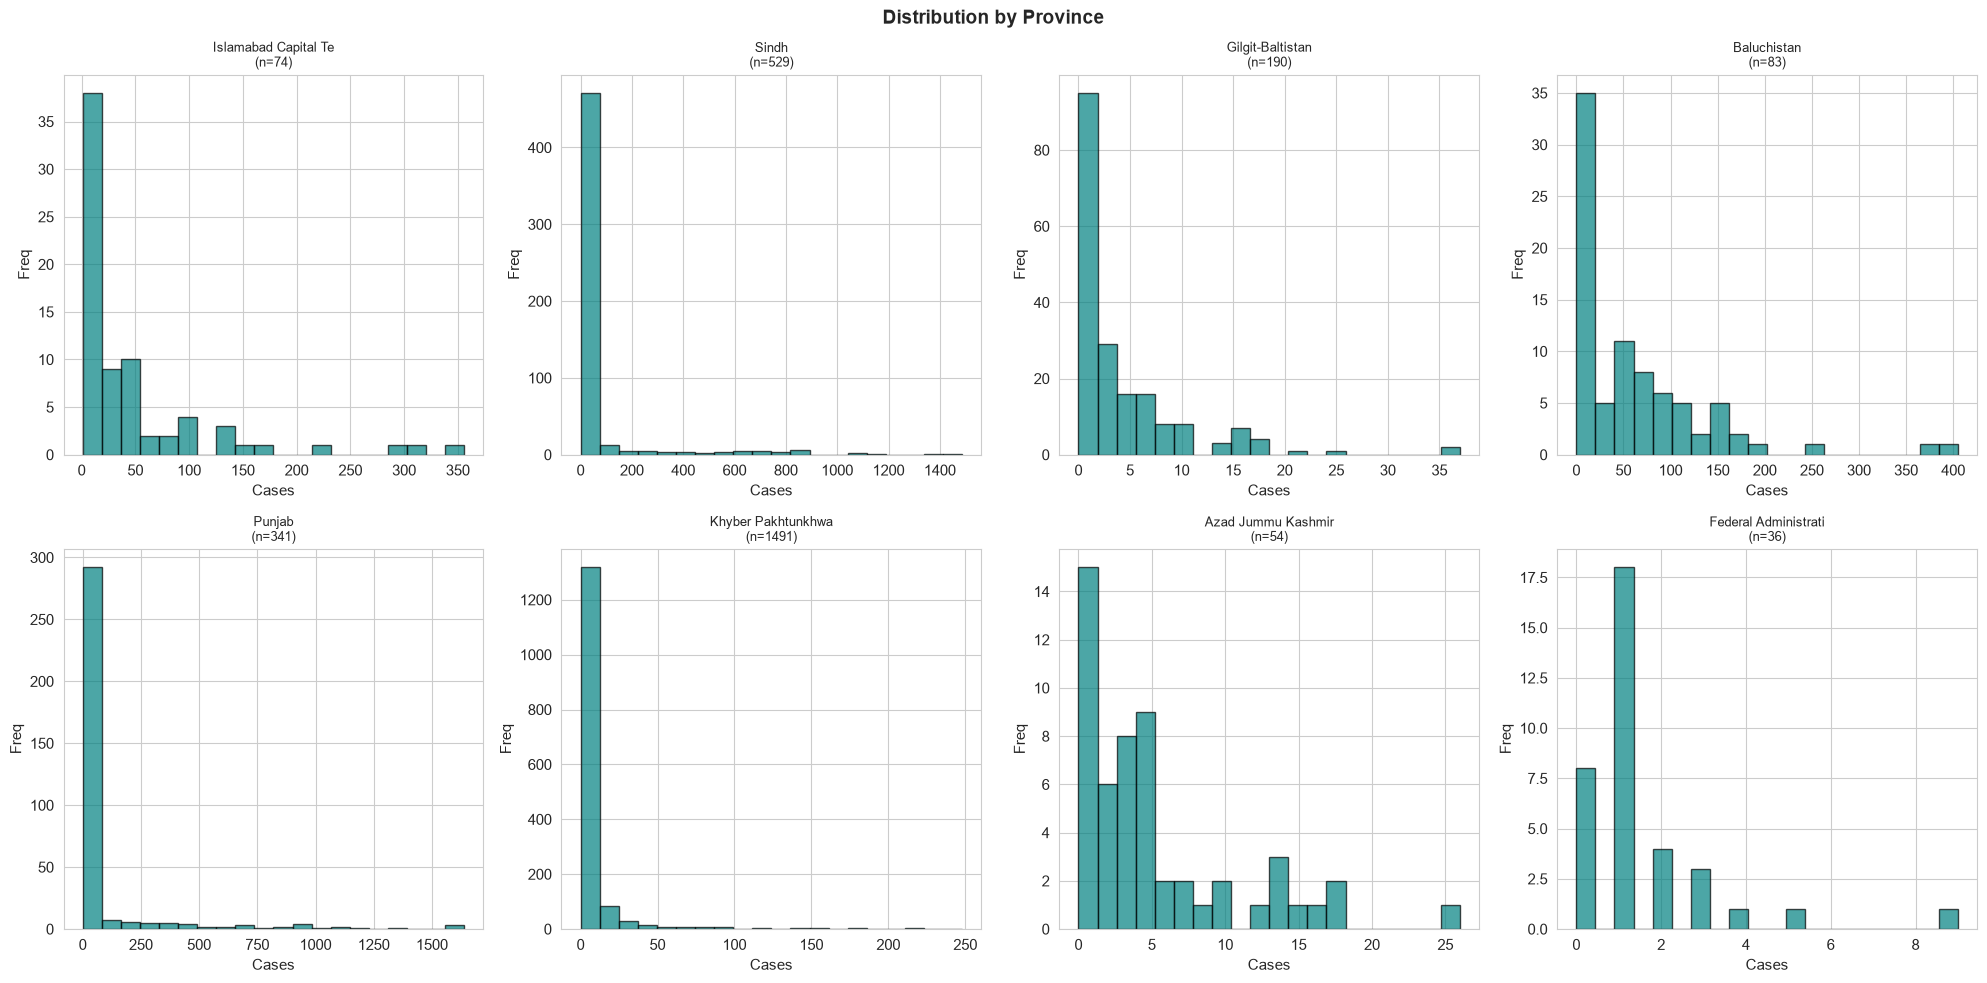

✅ 15_histogram_by_province.png


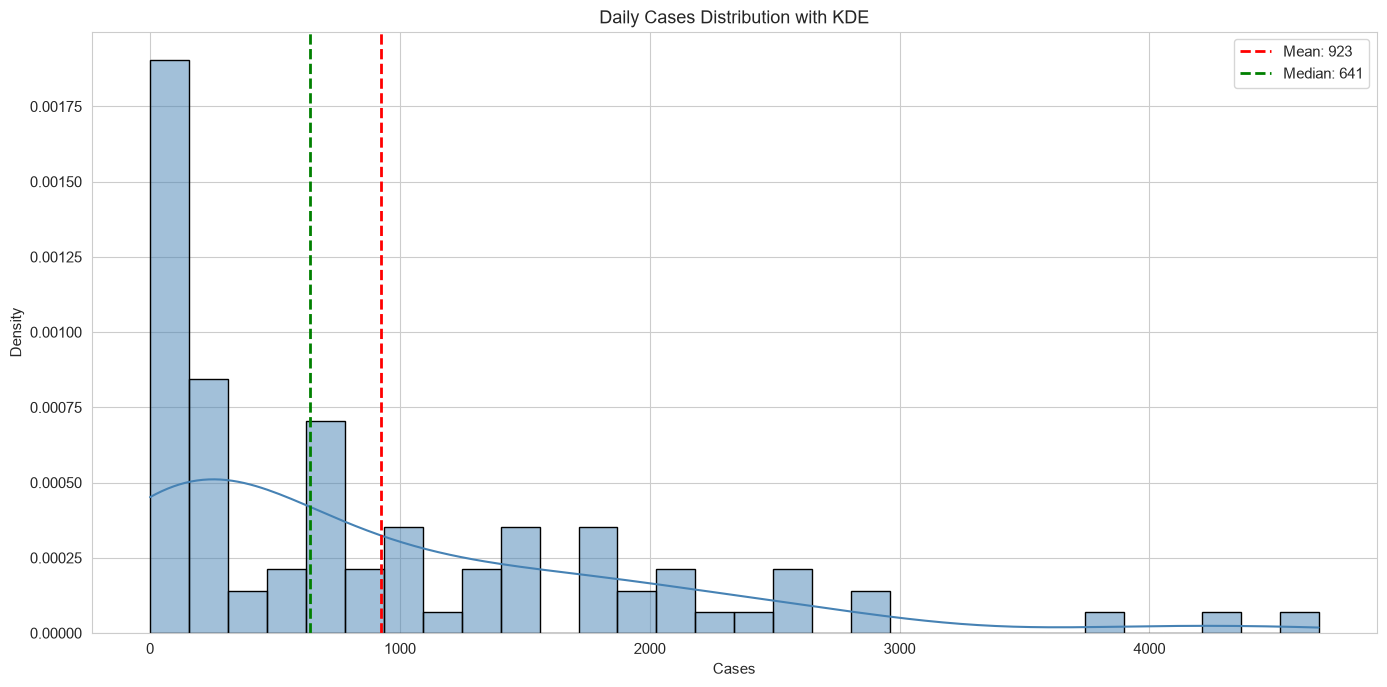

✅ 16_histogram_kde.png


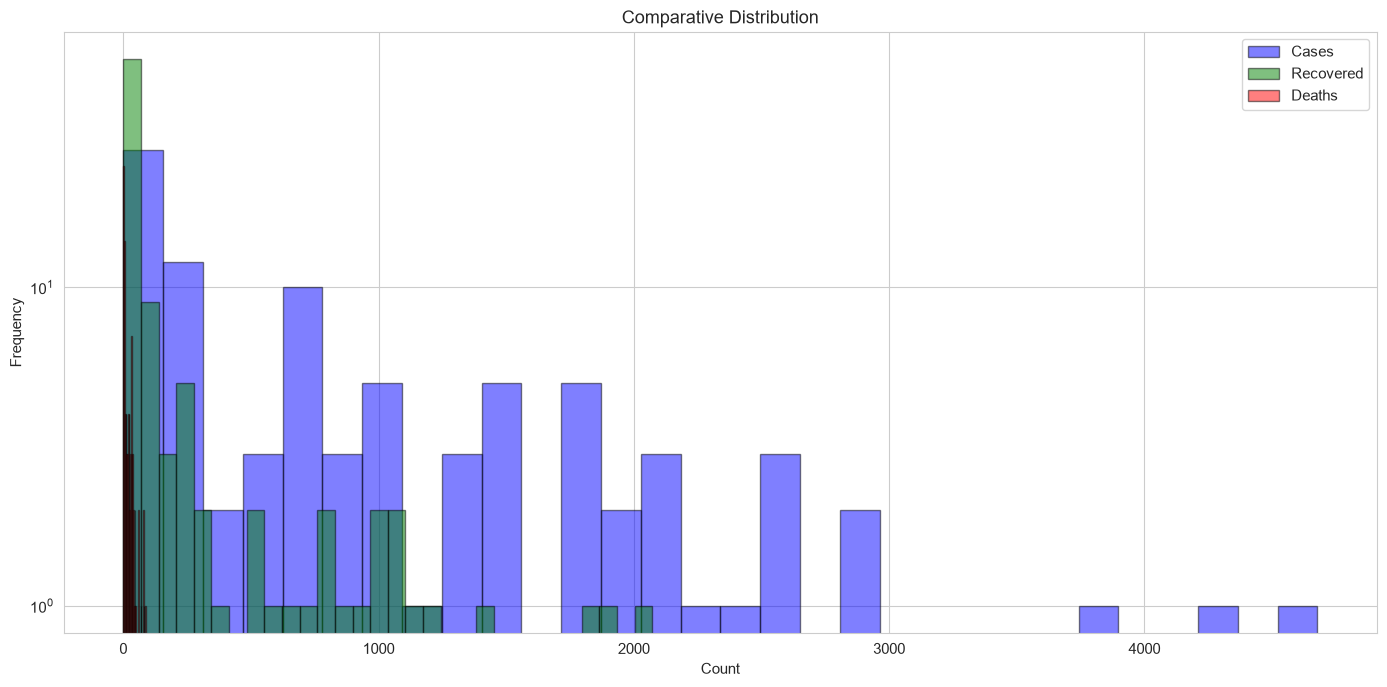

✅ 17_histogram_comparative.png

🎉 Cell 1 Complete — 4 histograms saved!


In [2]:
# ==========================================
# CELL 1: 4 HISTOGRAMS
# ==========================================

# 1.1: Log Scale
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, color in zip(axes, ['Cases', 'Deaths', 'Recovered'], ['steelblue', 'crimson', 'green']):
    data = daily[col][daily[col] > 0]
    ax.hist(np.log1p(data), bins=25, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'Log Distribution of {col}')
    ax.set_xlabel(f'Log({col}+1)')
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '14_histogram_log.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 14_histogram_log.png")

# 1.2: By Province
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
provinces = df['Province'].unique()
for i, prov in enumerate(provinces):
    data = df[df['Province'] == prov]['Cases']
    axes[i].hist(data, bins=20, color='teal', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{prov[:20]}\n(n={len(data)})', fontsize=9)
    axes[i].set_xlabel('Cases')
    axes[i].set_ylabel('Freq')
for j in range(len(provinces), len(axes)):
    axes[j].axis('off')
plt.suptitle('Distribution by Province', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '15_histogram_by_province.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 15_histogram_by_province.png")

# 1.3: KDE Overlay
fig, ax = plt.subplots(figsize=(14, 7))
sns.histplot(data=daily, x='Cases', kde=True, bins=30, color='steelblue',
             edgecolor='black', ax=ax, stat='density')
ax.axvline(daily['Cases'].mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean: {daily["Cases"].mean():.0f}')
ax.axvline(daily['Cases'].median(), color='green', linestyle='--', linewidth=2,
           label=f'Median: {daily["Cases"].median():.0f}')
ax.set_title('Daily Cases Distribution with KDE')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '16_histogram_kde.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 16_histogram_kde.png")

# 1.4: Comparative
fig, ax = plt.subplots(figsize=(14, 7))
ax.hist(daily['Cases'], bins=30, alpha=0.5, label='Cases', color='blue', edgecolor='black')
ax.hist(daily['Recovered'], bins=30, alpha=0.5, label='Recovered', color='green', edgecolor='black')
ax.hist(daily['Deaths'], bins=30, alpha=0.5, label='Deaths', color='red', edgecolor='black')
ax.set_title('Comparative Distribution')
ax.set_xlabel('Count')
ax.set_ylabel('Frequency')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '17_histogram_comparative.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 17_histogram_comparative.png")

print("\n🎉 Cell 1 Complete — 4 histograms saved!")

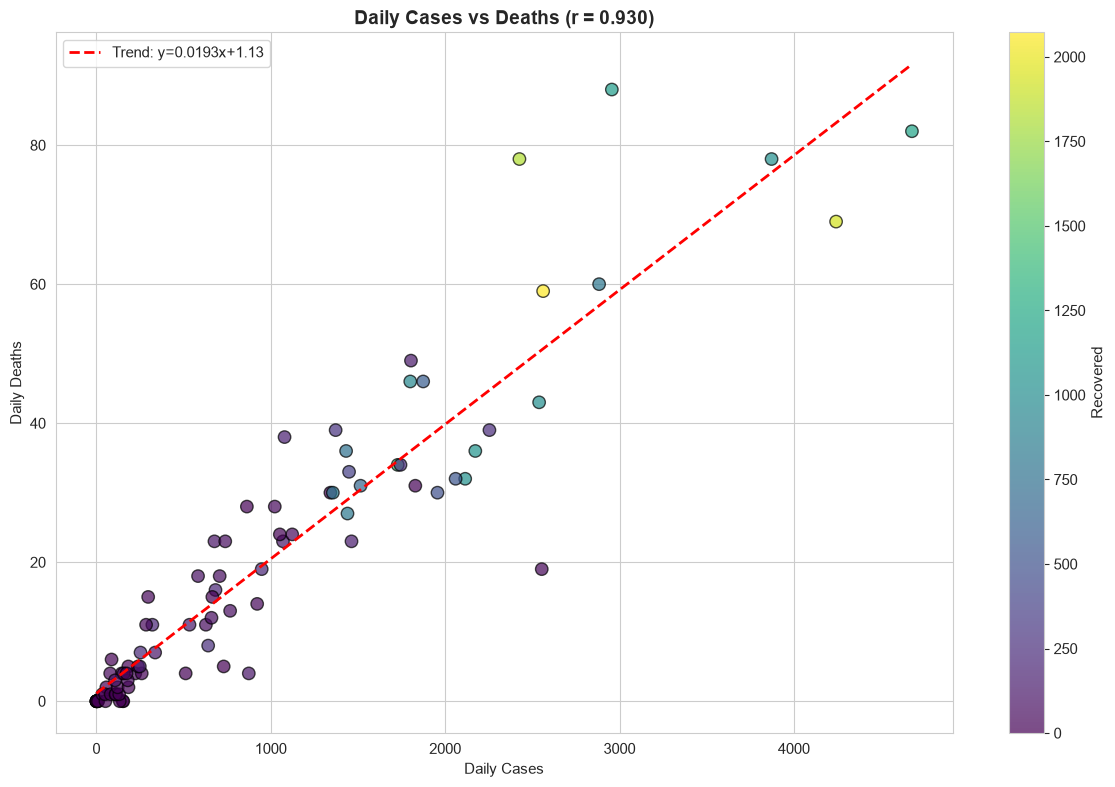

✅ 18_scatter_cases_deaths.png


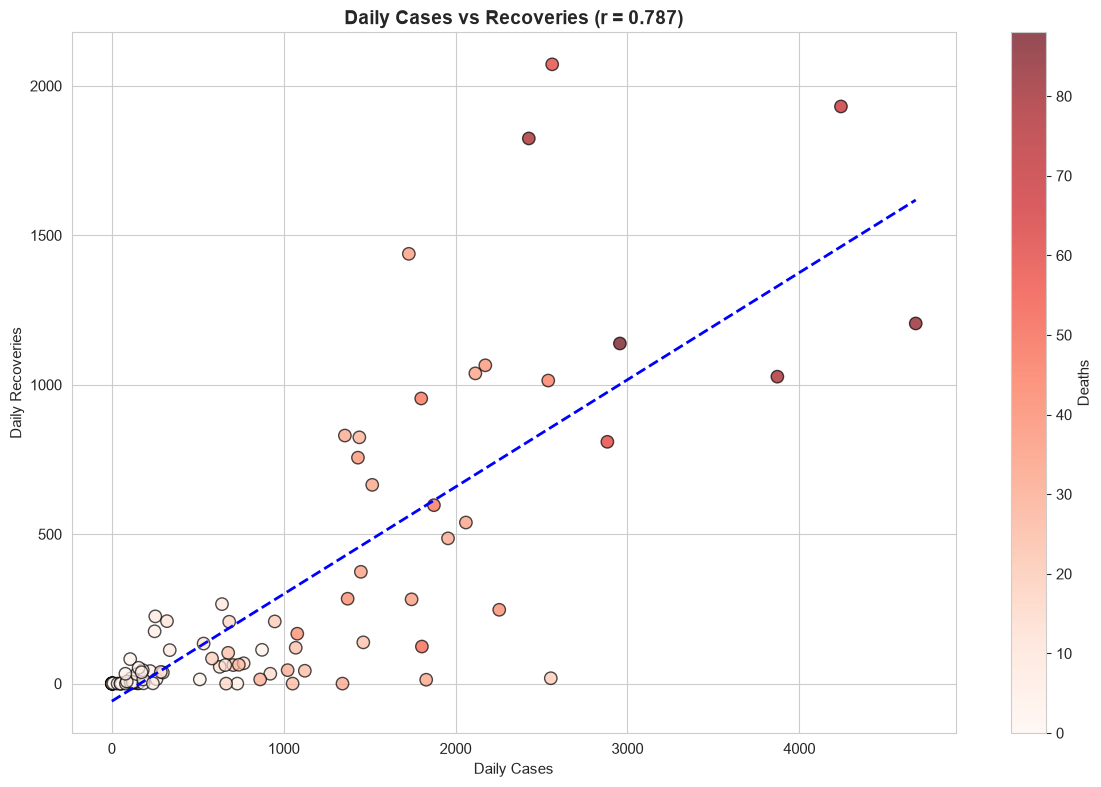

✅ 19_scatter_cases_recoveries.png


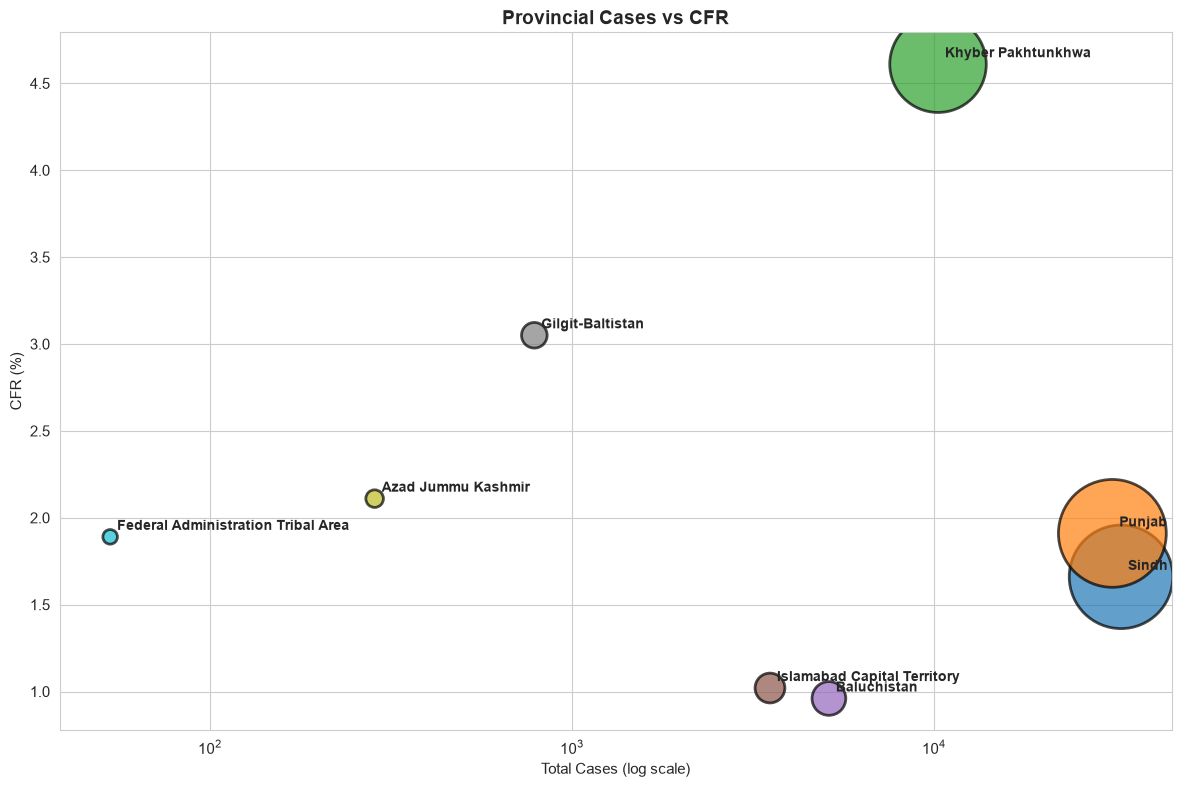

✅ 20_scatter_province_cfr.png


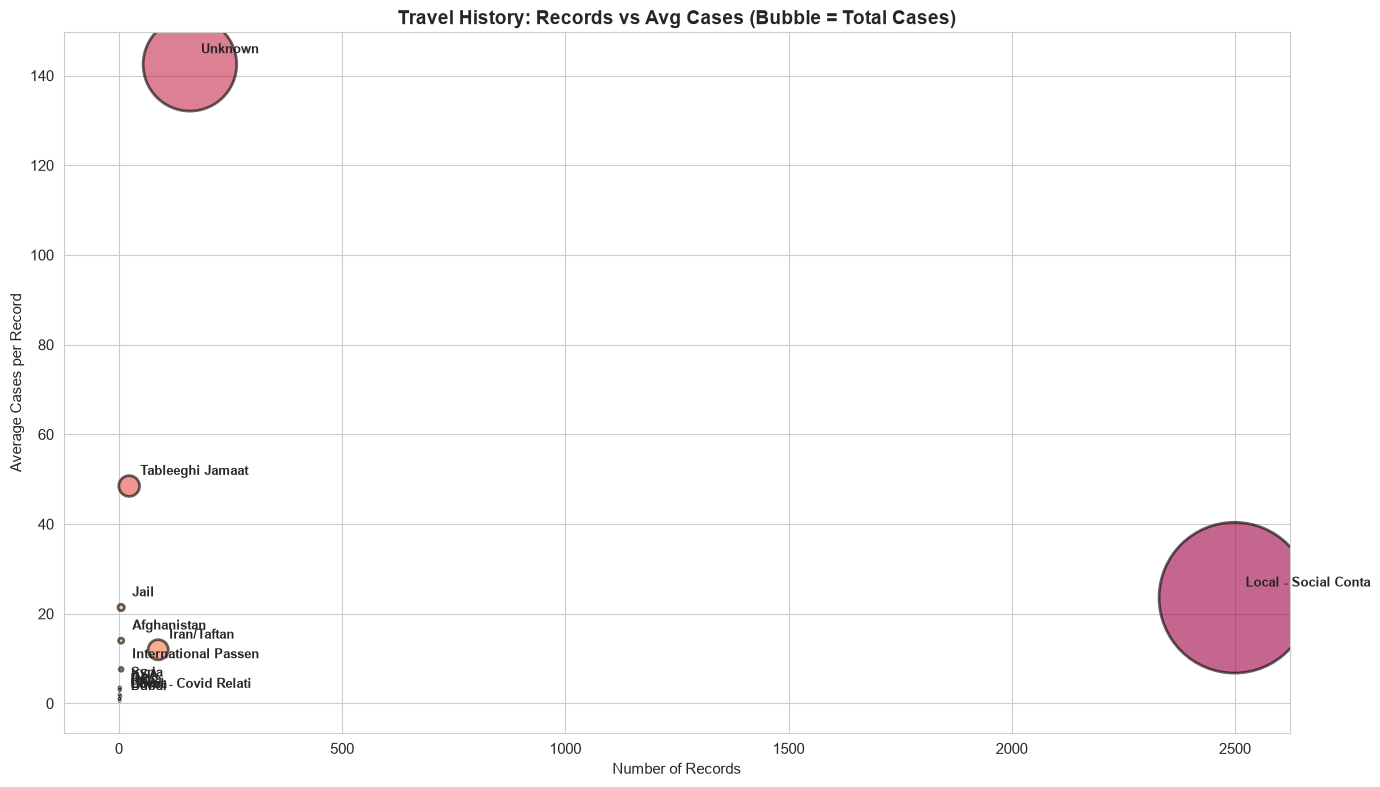

✅ 21_scatter_travel_bubble.png


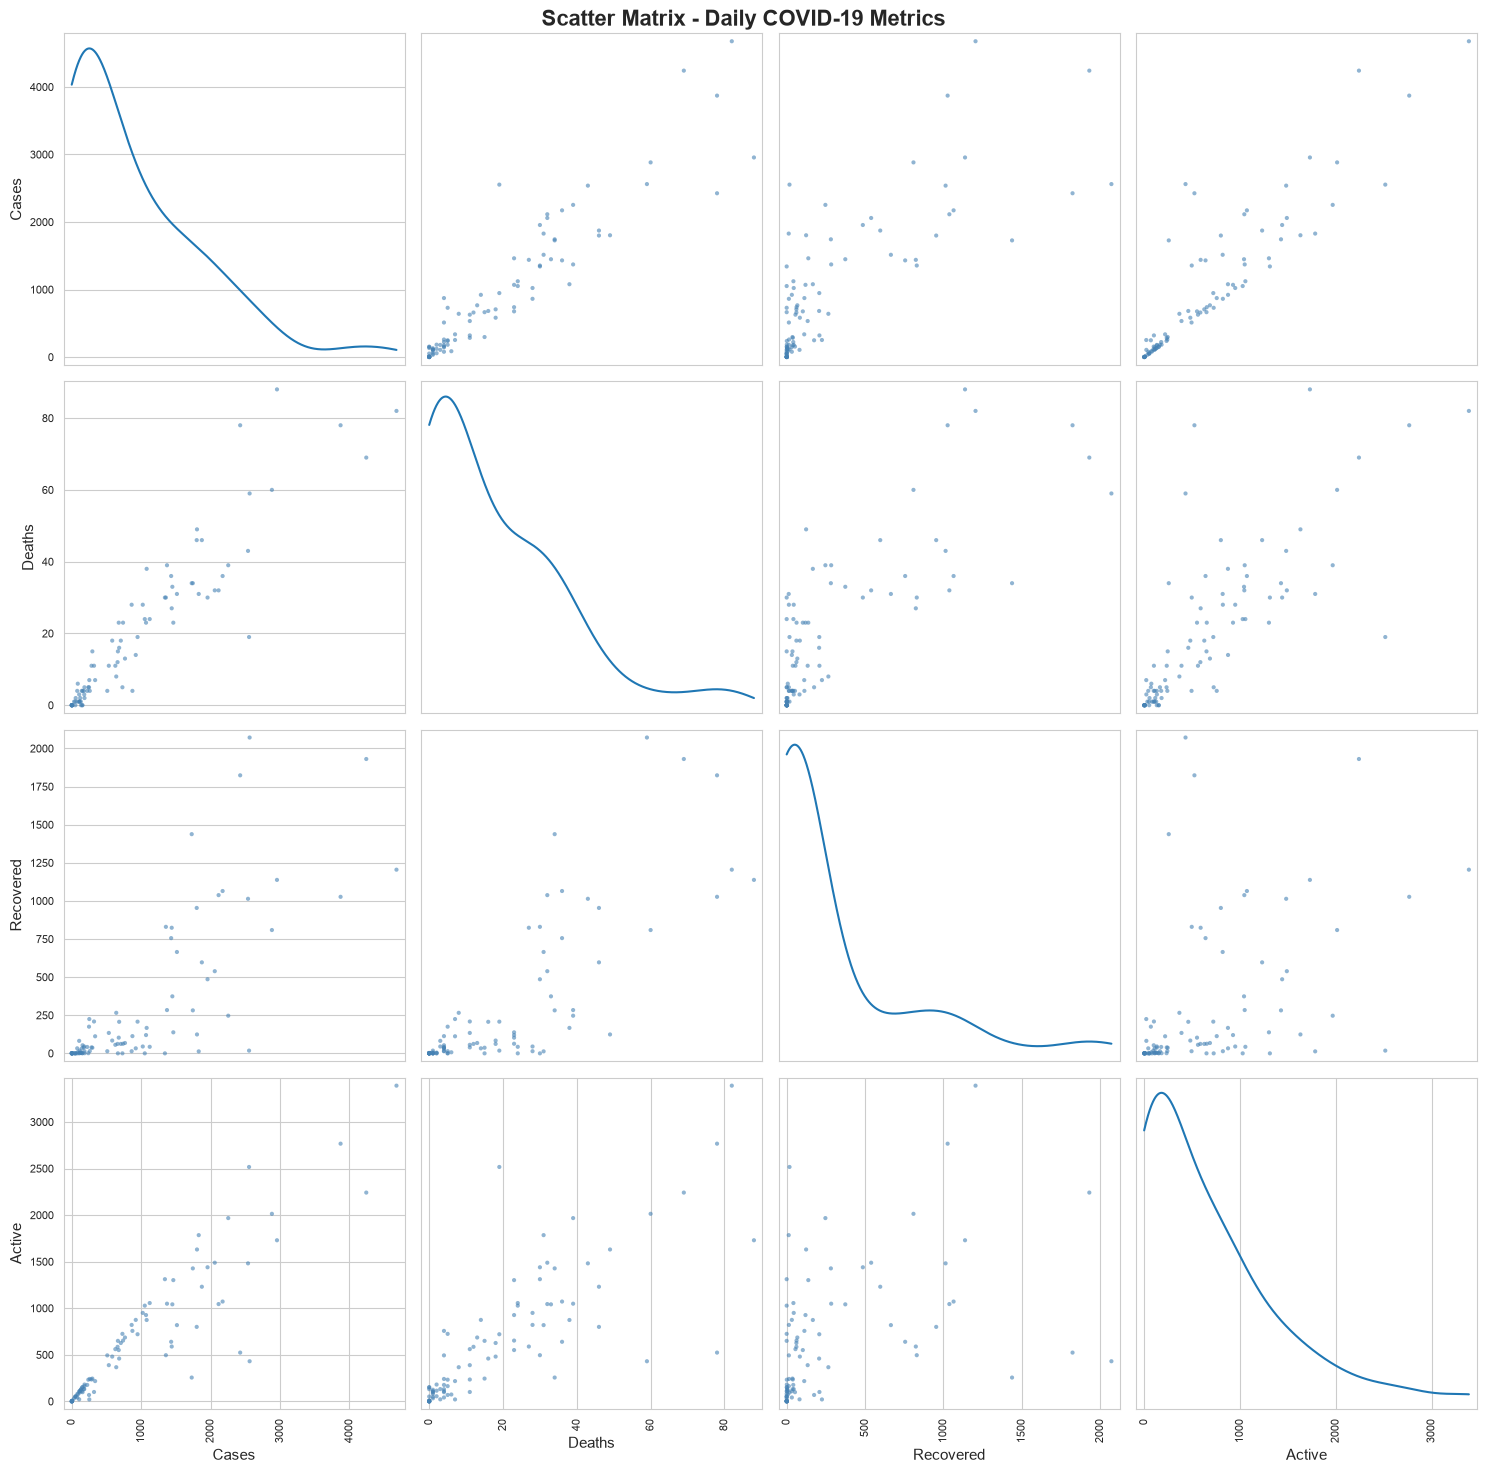

✅ 22_scatter_matrix.png


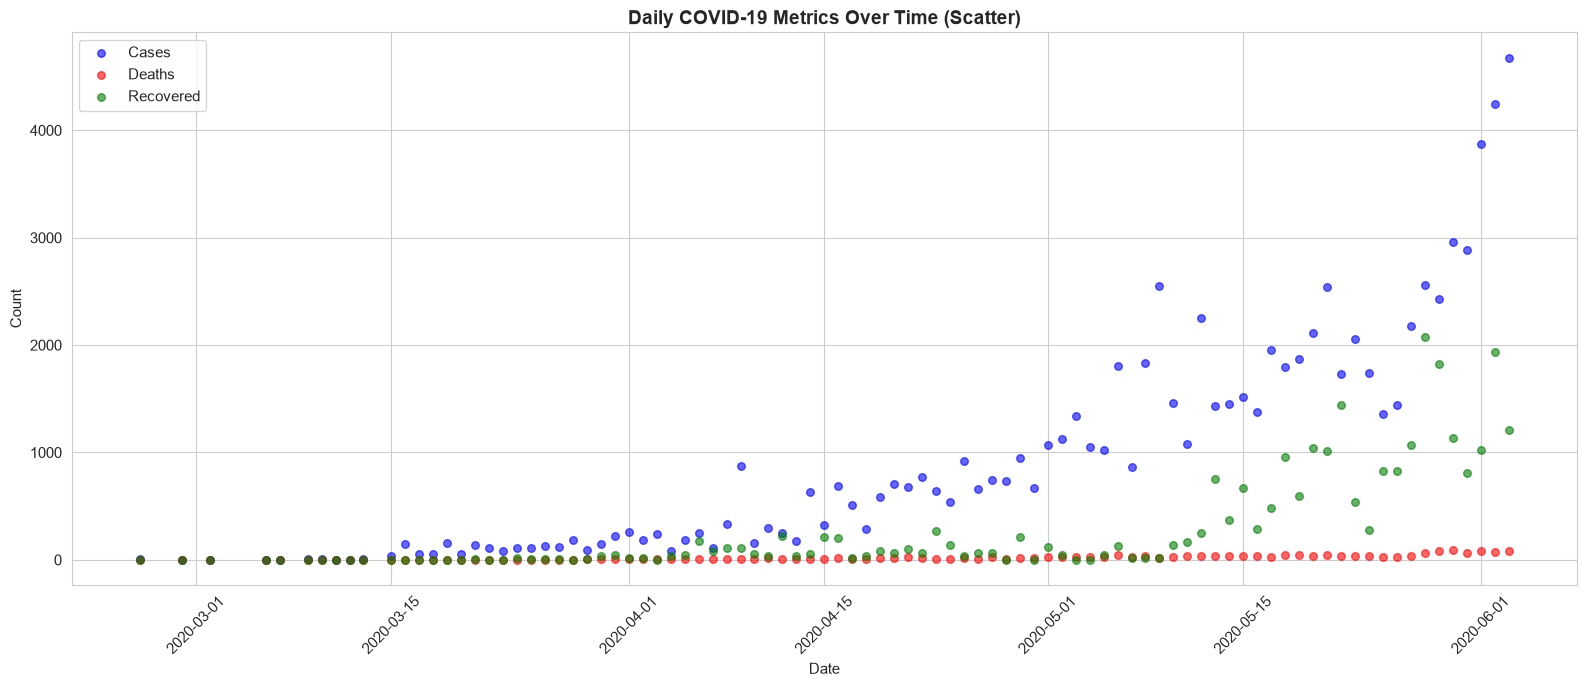

✅ 23_scatter_time_series.png

🎉 Cell 2 Complete — 6 scatter plots saved!


In [3]:
# ==========================================
# CELL 2: 6 SCATTER PLOTS
# ==========================================

# 2.1: Cases vs Deaths
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(daily['Cases'], daily['Deaths'], c=daily['Recovered'],
                     cmap='viridis', s=80, alpha=0.7, edgecolors='black')
z = np.polyfit(daily['Cases'], daily['Deaths'], 1)
p = np.poly1d(z)
x_line = np.linspace(daily['Cases'].min(), daily['Cases'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, label=f'Trend: y={z[0]:.4f}x+{z[1]:.2f}')
corr = daily['Cases'].corr(daily['Deaths'])
ax.set_title(f'Daily Cases vs Deaths (r = {corr:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Cases')
ax.set_ylabel('Daily Deaths')
ax.legend()
plt.colorbar(scatter, label='Recovered')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '18_scatter_cases_deaths.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 18_scatter_cases_deaths.png")

# 2.2: Cases vs Recoveries
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(daily['Cases'], daily['Recovered'], c=daily['Deaths'],
                     cmap='Reds', s=80, alpha=0.7, edgecolors='black')
z = np.polyfit(daily['Cases'], daily['Recovered'], 1)
p = np.poly1d(z)
x_line = np.linspace(daily['Cases'].min(), daily['Cases'].max(), 100)
ax.plot(x_line, p(x_line), "b--", linewidth=2)
corr = daily['Cases'].corr(daily['Recovered'])
ax.set_title(f'Daily Cases vs Recoveries (r = {corr:.3f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Cases')
ax.set_ylabel('Daily Recoveries')
plt.colorbar(scatter, label='Deaths')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '19_scatter_cases_recoveries.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 19_scatter_cases_recoveries.png")

# 2.3: Province Cases vs CFR
fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(province_summary['Cases'], province_summary['CFR'],
                     s=province_summary['Deaths']*10 + 100,
                     c=range(len(province_summary)), cmap='tab10',
                     alpha=0.7, edgecolors='black', linewidth=2)
for i, row in province_summary.iterrows():
    ax.annotate(row['Province'], (row['Cases'], row['CFR']),
                xytext=(5, 5), textcoords='offset points',
                fontsize=10, fontweight='bold')
ax.set_title('Provincial Cases vs CFR', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Cases (log scale)')
ax.set_ylabel('CFR (%)')
ax.set_xscale('log')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '20_scatter_province_cfr.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 20_scatter_province_cfr.png")

# 2.4: Travel History Bubble
fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(travel_summary['Records'], travel_summary['Avg_Cases_per_Record'],
                     s=travel_summary['Cases']/5,
                     c=range(len(travel_summary)), cmap='Spectral',
                     alpha=0.6, edgecolors='black', linewidth=2)
for i, row in travel_summary.iterrows():
    ax.annotate(row['Travel_history'][:20], (row['Records'], row['Avg_Cases_per_Record']),
                xytext=(8, 8), textcoords='offset points',
                fontsize=9, fontweight='bold')
ax.set_title('Travel History: Records vs Avg Cases (Bubble = Total Cases)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Records')
ax.set_ylabel('Average Cases per Record')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '21_scatter_travel_bubble.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 21_scatter_travel_bubble.png")

# 2.5: Scatter Matrix
from pandas.plotting import scatter_matrix
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
scatter_matrix(daily[['Cases', 'Deaths', 'Recovered', 'Active']],
               alpha=0.6, diagonal='kde', color='steelblue', ax=axes)
plt.suptitle('Scatter Matrix - Daily COVID-19 Metrics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '22_scatter_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 22_scatter_matrix.png")

# 2.6: Time Series Scatter
fig, ax = plt.subplots(figsize=(16, 7))
ax.scatter(daily['Date'], daily['Cases'], c='blue', s=30, alpha=0.6, label='Cases')
ax.scatter(daily['Date'], daily['Deaths'], c='red', s=30, alpha=0.6, label='Deaths')
ax.scatter(daily['Date'], daily['Recovered'], c='green', s=30, alpha=0.6, label='Recovered')
ax.set_title('Daily COVID-19 Metrics Over Time (Scatter)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '23_scatter_time_series.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 23_scatter_time_series.png")

print("\n🎉 Cell 2 Complete — 6 scatter plots saved!")

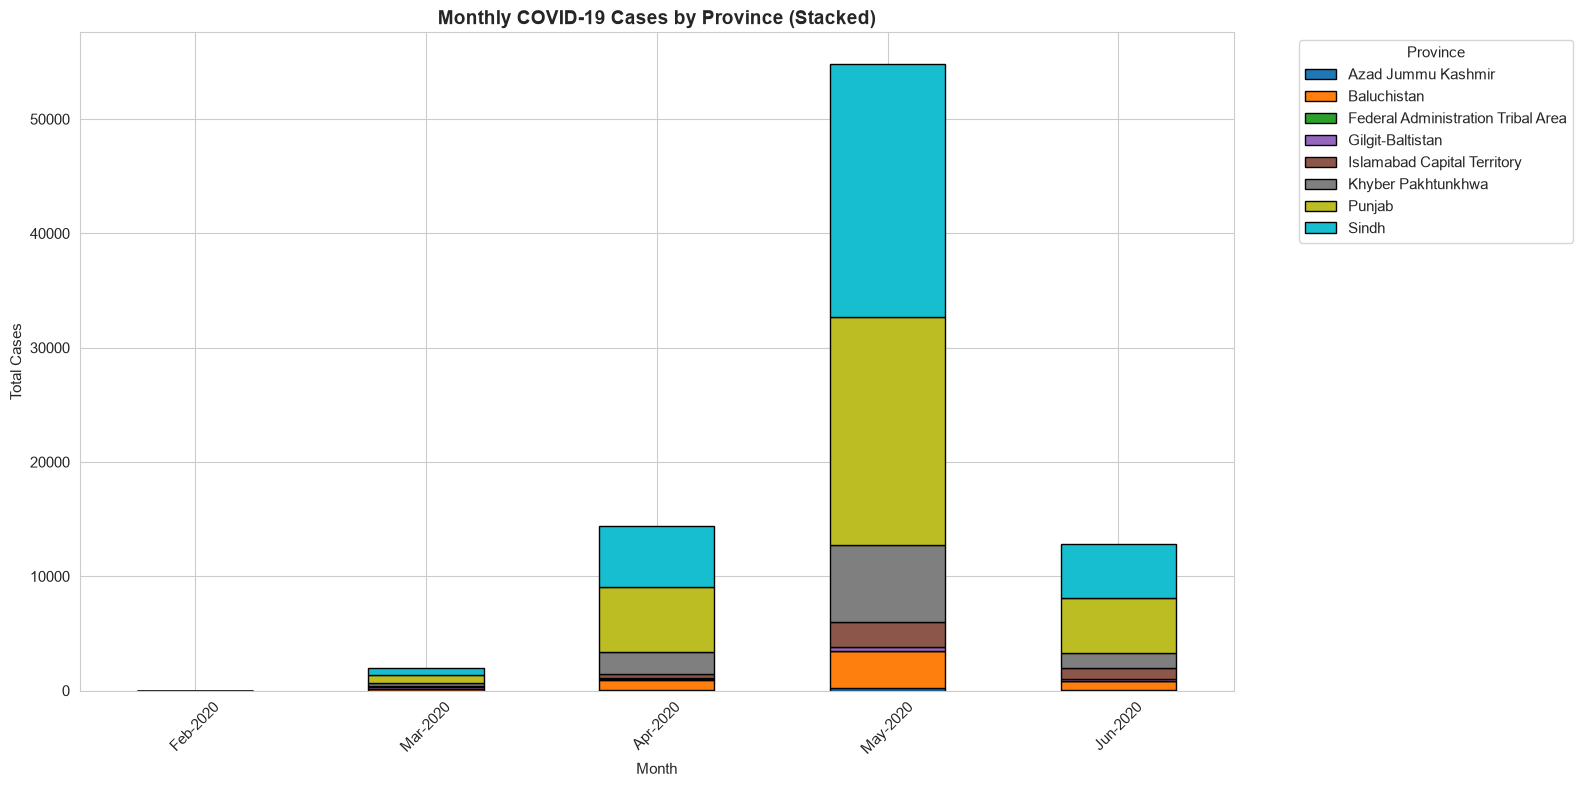

✅ 24_pivot_province_stacked.png


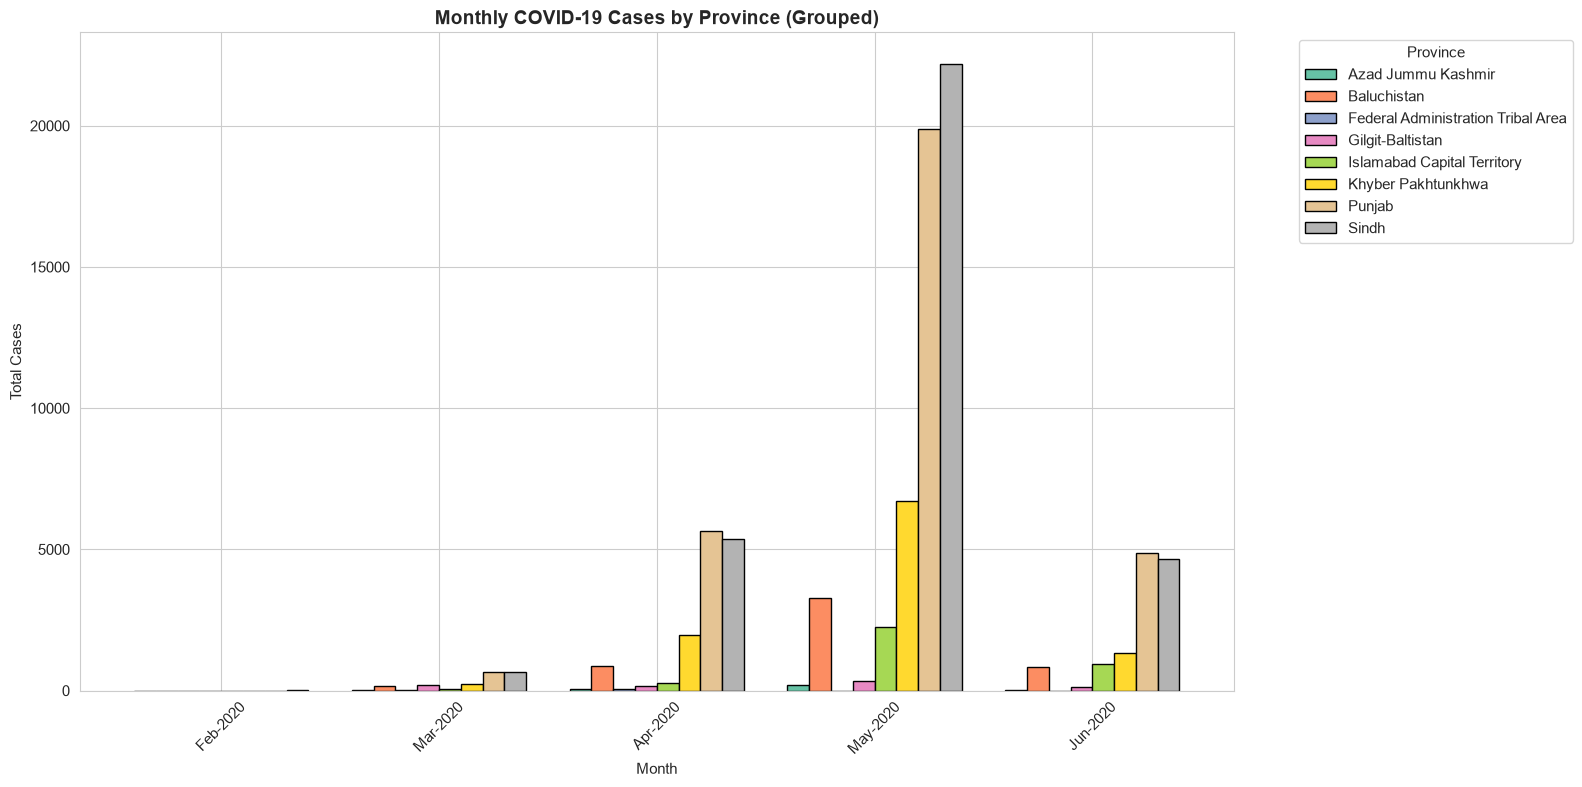

✅ 25_pivot_province_grouped.png


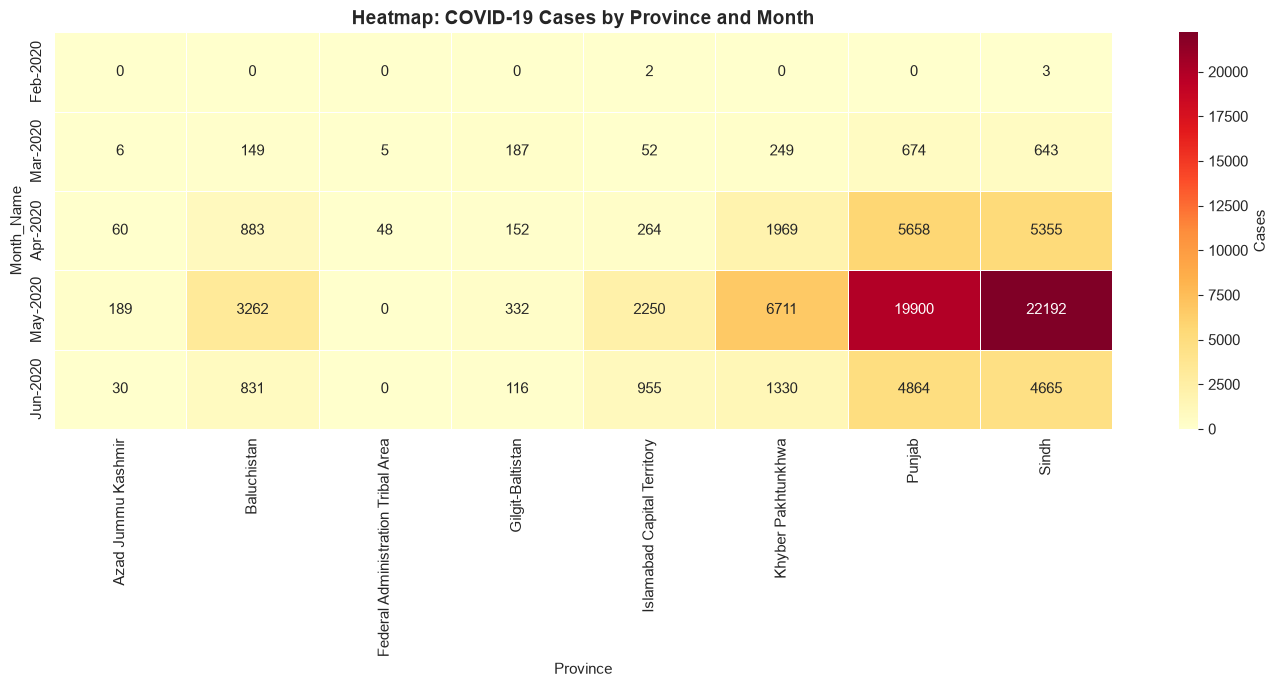

✅ 26_pivot_heatmap_province_month.png


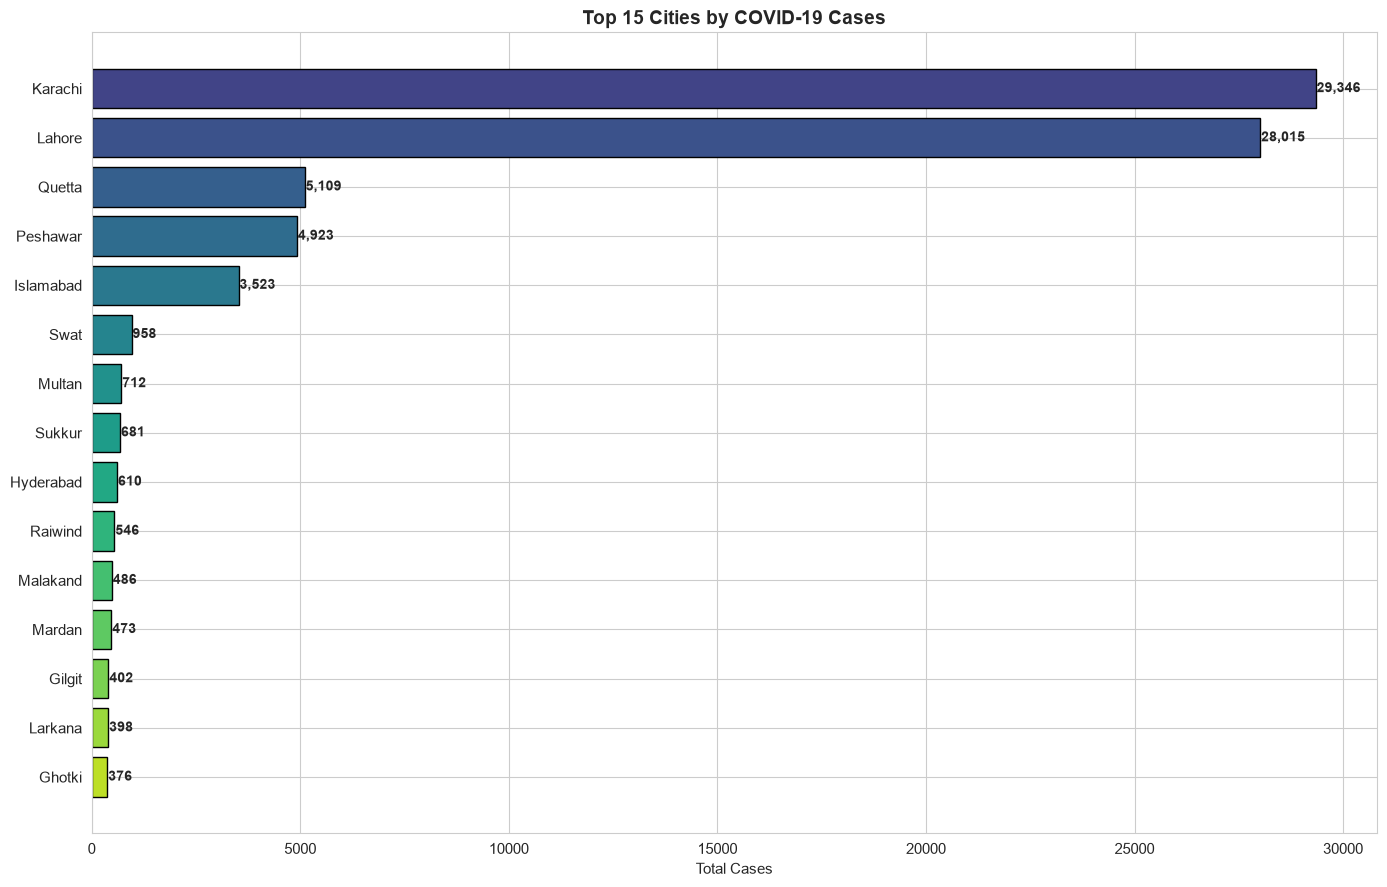

✅ 27_pivot_top_cities.png


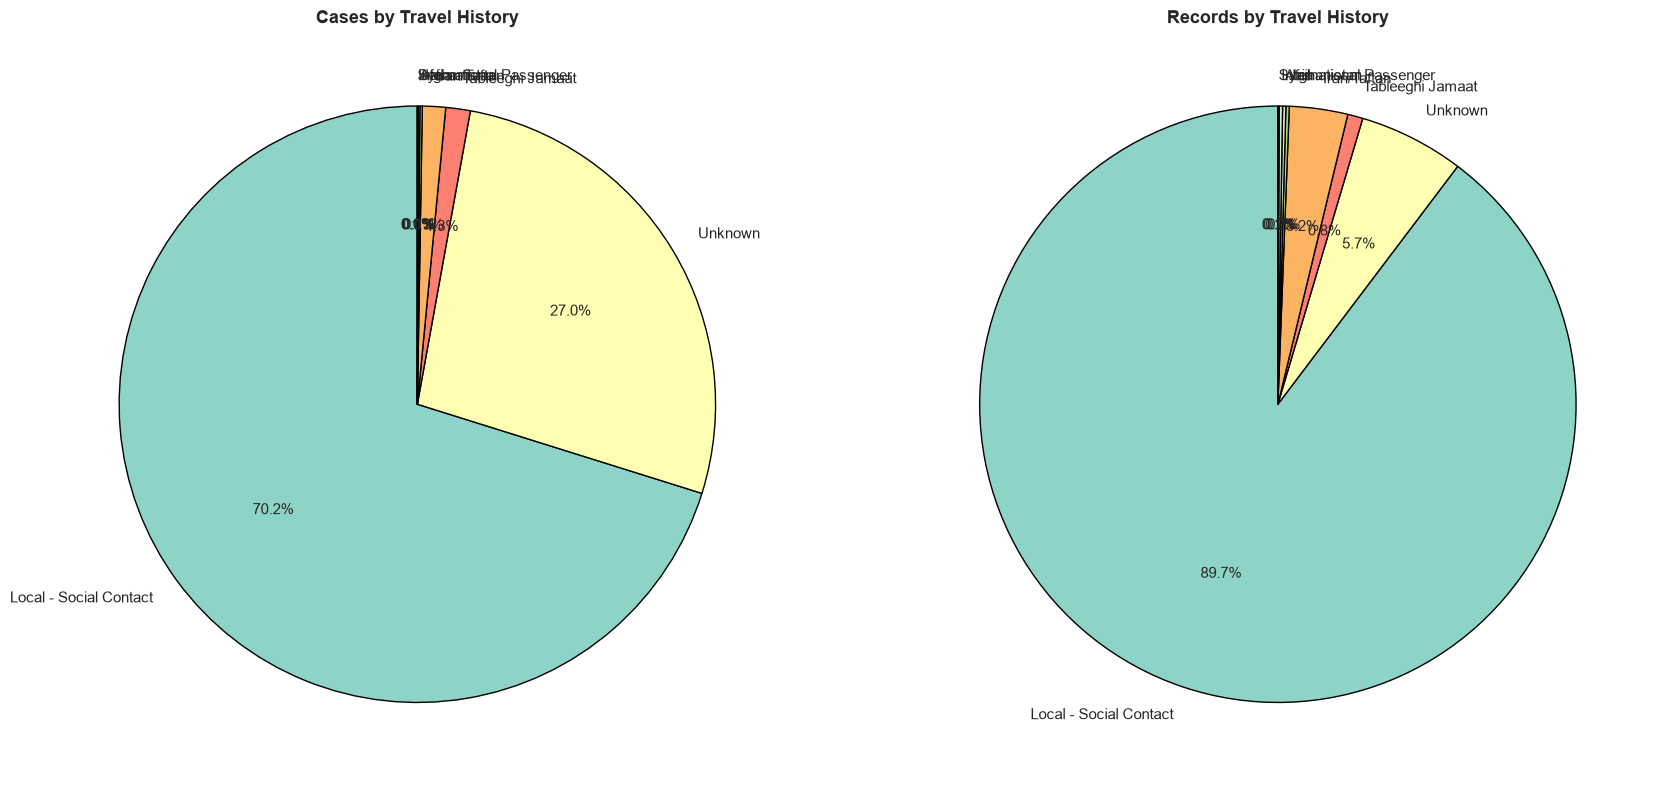

✅ 28_pivot_travel_pie.png


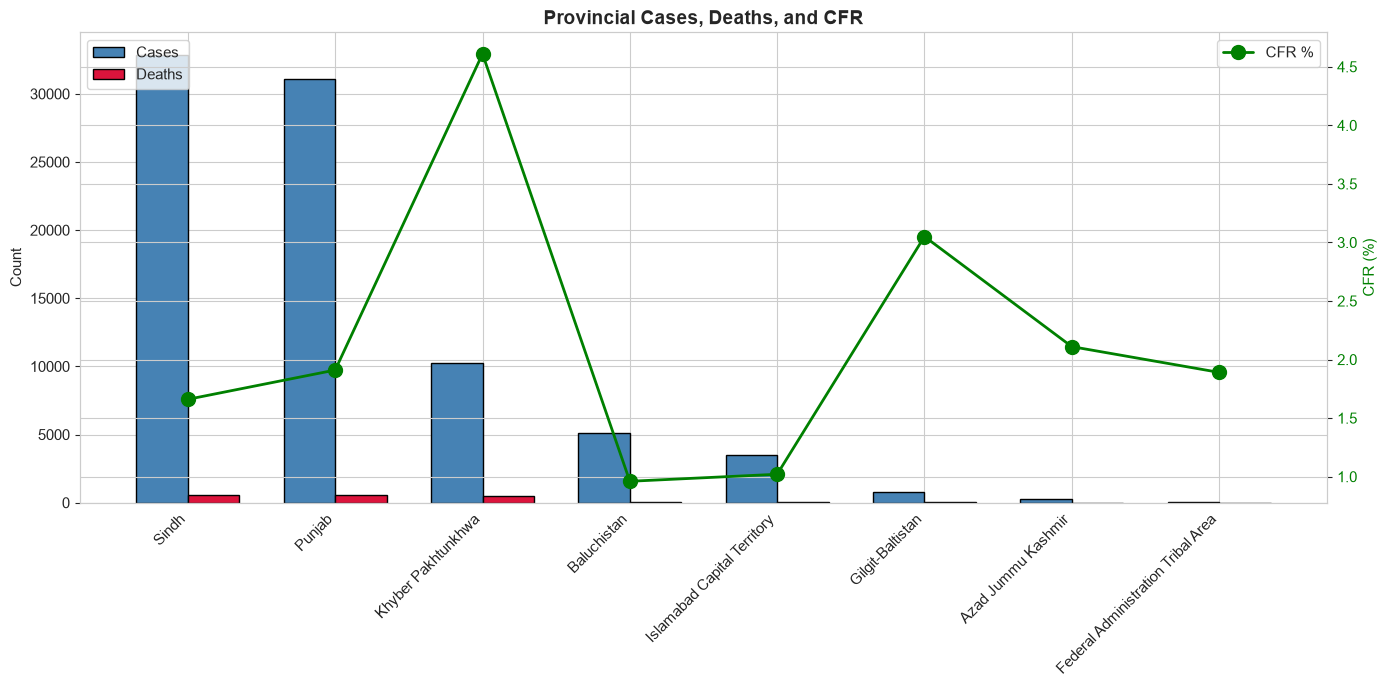

✅ 29_pivot_cfr_combo.png


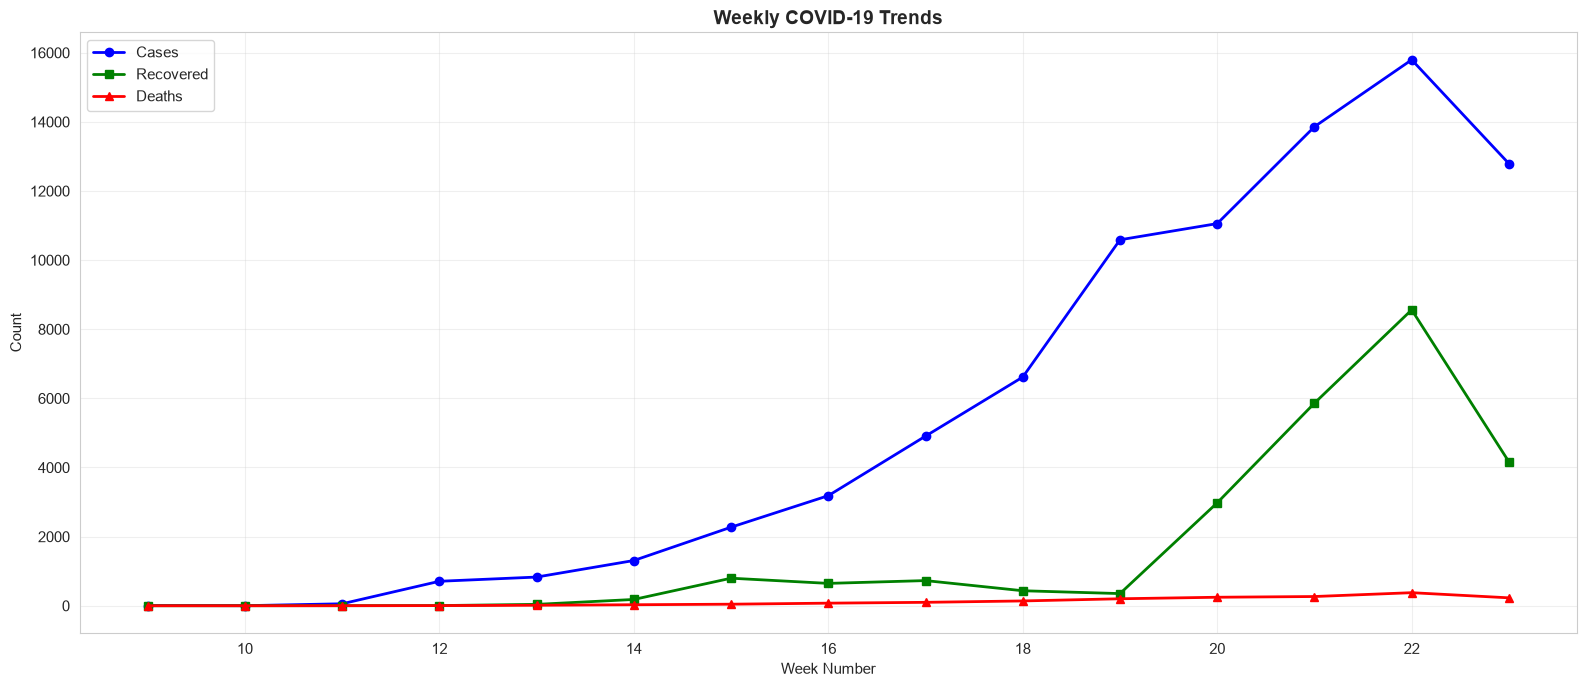

✅ 30_pivot_weekly_trend.png


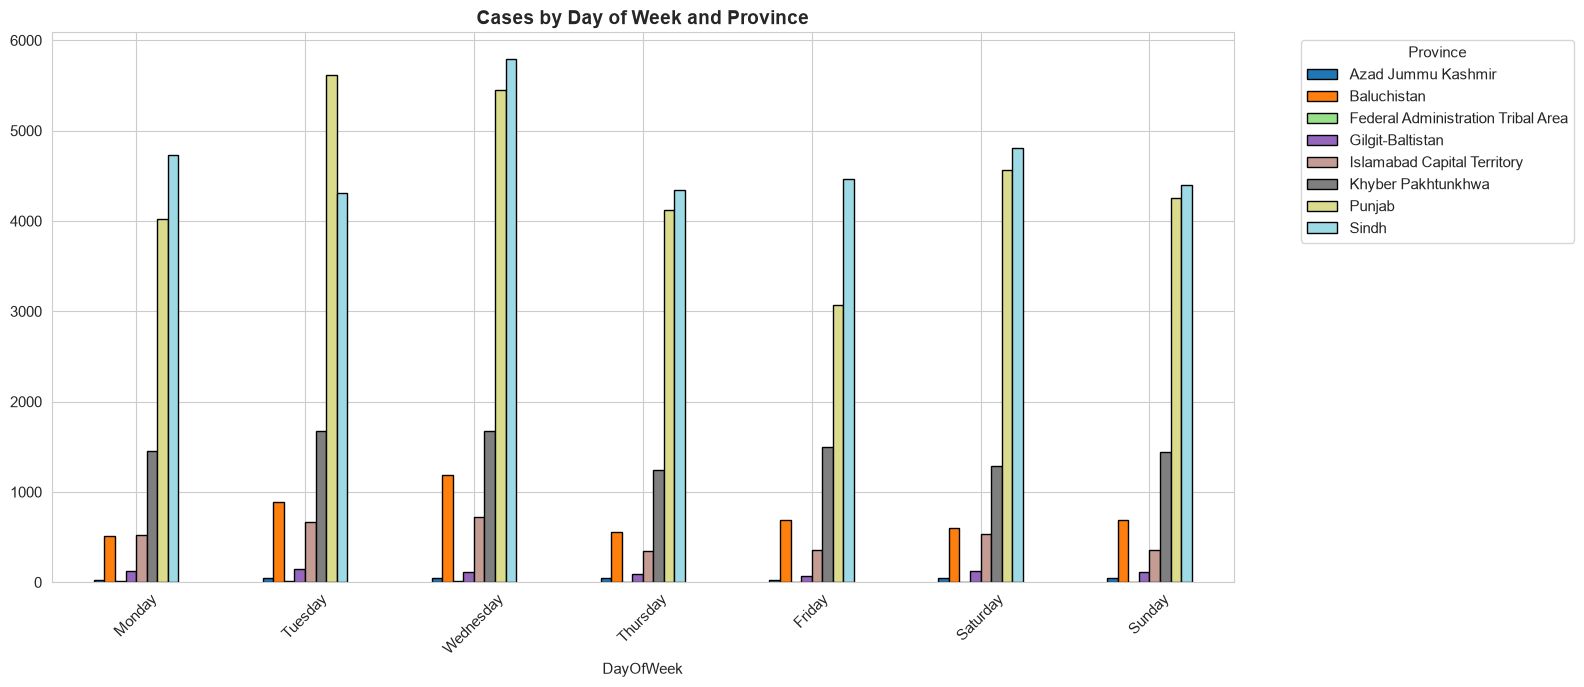

✅ 31_pivot_dow_province.png

🎉 Cell 3 Complete — 8 pivot charts saved!


In [4]:
# ==========================================
# CELL 3: 8 PIVOT CHARTS
# ==========================================

# 3.1: Stacked Bar (Province × Month)
fig, ax = plt.subplots(figsize=(16, 8))
pivot_prov_time.plot(kind='bar', stacked=True, ax=ax, colormap='tab10', edgecolor='black')
ax.set_title('Monthly COVID-19 Cases by Province (Stacked)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Cases')
ax.legend(title='Province', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '24_pivot_province_stacked.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 24_pivot_province_stacked.png")

# 3.2: Grouped Bar
fig, ax = plt.subplots(figsize=(16, 8))
pivot_prov_time.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', width=0.8)
ax.set_title('Monthly COVID-19 Cases by Province (Grouped)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Cases')
ax.legend(title='Province', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '25_pivot_province_grouped.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 25_pivot_province_grouped.png")

# 3.3: Heatmap Province × Month
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(pivot_prov_time, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Cases'})
ax.set_title('Heatmap: COVID-19 Cases by Province and Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '26_pivot_heatmap_province_month.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 26_pivot_heatmap_province_month.png")

# 3.4: Top 15 Cities
top15 = city_summary.head(15)
fig, ax = plt.subplots(figsize=(14, 9))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top15)))
bars = ax.barh(top15['City'], top15['Cases'], color=colors, edgecolor='black')
for bar, val in zip(bars, top15['Cases']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')
ax.invert_yaxis()
ax.set_title('Top 15 Cities by COVID-19 Cases', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Cases')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '27_pivot_top_cities.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 27_pivot_top_cities.png")

# 3.5: Travel History Pie
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
top_travel = travel_summary.head(8)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_travel)))
axes[0].pie(top_travel['Cases'], labels=top_travel['Travel_history'], autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[0].set_title('Cases by Travel History', fontsize=13, fontweight='bold')
axes[1].pie(top_travel['Records'], labels=top_travel['Travel_history'], autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[1].set_title('Records by Travel History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '28_pivot_travel_pie.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 28_pivot_travel_pie.png")

# 3.6: CFR Combo Chart
fig, ax1 = plt.subplots(figsize=(14, 7))
x = np.arange(len(province_summary))
width = 0.35
ax1.bar(x - width/2, province_summary['Cases'], width, label='Cases', color='steelblue', edgecolor='black')
ax1.bar(x + width/2, province_summary['Deaths'], width, label='Deaths', color='crimson', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(province_summary['Province'], rotation=45, ha='right')
ax1.set_ylabel('Count')
ax1.legend(loc='upper left')
ax2 = ax1.twinx()
ax2.plot(x, province_summary['CFR'], 'go-', linewidth=2, markersize=10, label='CFR %')
ax2.set_ylabel('CFR (%)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')
ax1.set_title('Provincial Cases, Deaths, and CFR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '29_pivot_cfr_combo.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 29_pivot_cfr_combo.png")

# 3.7: Weekly Trend
weekly = df.groupby('Week').agg({'Cases': 'sum', 'Deaths': 'sum', 'Recovered': 'sum'}).reset_index()
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(weekly['Week'], weekly['Cases'], 'o-', color='blue', linewidth=2, label='Cases')
ax.plot(weekly['Week'], weekly['Recovered'], 's-', color='green', linewidth=2, label='Recovered')
ax.plot(weekly['Week'], weekly['Deaths'], '^-', color='red', linewidth=2, label='Deaths')
ax.set_title('Weekly COVID-19 Trends', fontsize=14, fontweight='bold')
ax.set_xlabel('Week Number')
ax.set_ylabel('Count')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '30_pivot_weekly_trend.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 30_pivot_weekly_trend.png")

# 3.8: Day of Week Analysis
dow_pivot = df.pivot_table(values='Cases', index='DayOfWeek', columns='Province',
                           aggfunc='sum', fill_value=0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_pivot = dow_pivot.reindex(day_order)
fig, ax = plt.subplots(figsize=(16, 7))
dow_pivot.plot(kind='bar', ax=ax, colormap='tab20', edgecolor='black')
ax.set_title('Cases by Day of Week and Province', fontsize=14, fontweight='bold')
ax.legend(title='Province', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '31_pivot_dow_province.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 31_pivot_dow_province.png")

print("\n🎉 Cell 3 Complete — 8 pivot charts saved!")

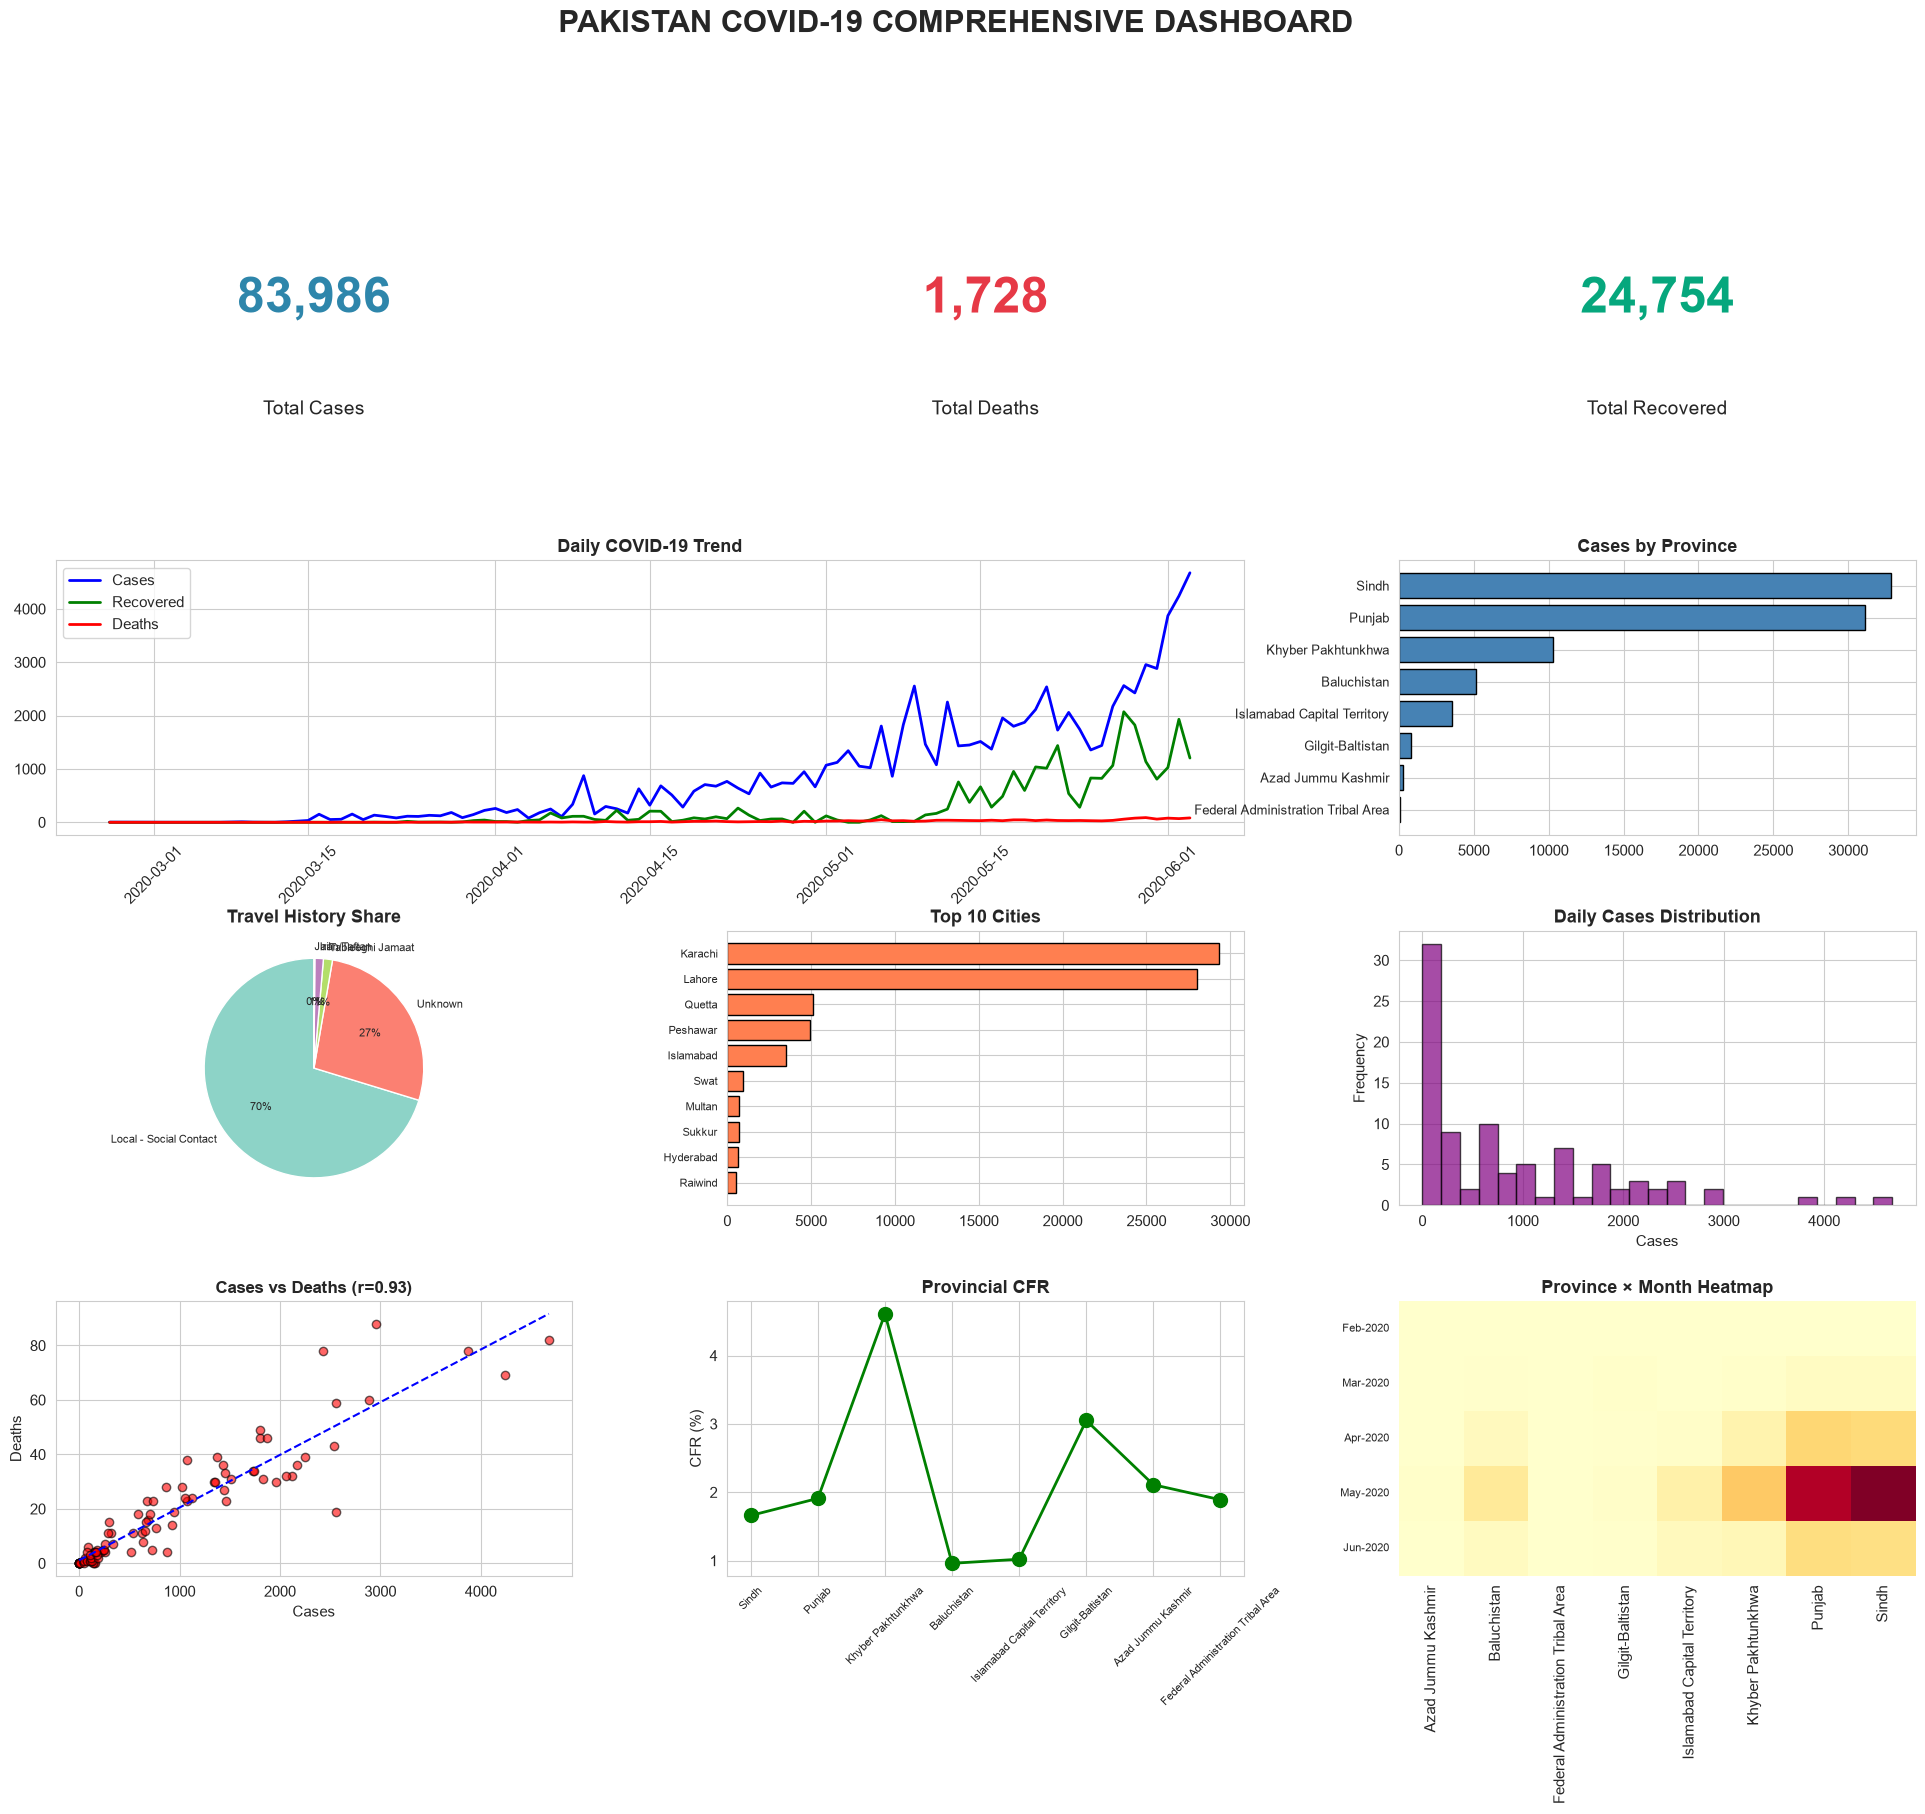

✅ 32_master_dashboard.png
🎉 Cell 4 Complete — Master Dashboard saved!


In [5]:
# ==========================================
# CELL 4: MASTER DASHBOARD (4×3 Grid)
# ==========================================

fig = plt.figure(figsize=(24, 18))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

# ==================== Row 1: KPI Cards ====================
ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi1.text(0.5, 0.6, f"{daily['Cumulative_Cases'].iloc[-1]:,.0f}",
             ha='center', va='center', fontsize=36, fontweight='bold', color='#2E86AB')
ax_kpi1.text(0.5, 0.2, "Total Cases", ha='center', va='center', fontsize=14)
ax_kpi1.axis('off')

ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi2.text(0.5, 0.6, f"{daily['Cumulative_Deaths'].iloc[-1]:,.0f}",
             ha='center', va='center', fontsize=36, fontweight='bold', color='#E63946')
ax_kpi2.text(0.5, 0.2, "Total Deaths", ha='center', va='center', fontsize=14)
ax_kpi2.axis('off')

ax_kpi3 = fig.add_subplot(gs[0, 2])
ax_kpi3.text(0.5, 0.6, f"{daily['Cumulative_Recovered'].iloc[-1]:,.0f}",
             ha='center', va='center', fontsize=36, fontweight='bold', color='#06A77D')
ax_kpi3.text(0.5, 0.2, "Total Recovered", ha='center', va='center', fontsize=14)
ax_kpi3.axis('off')

# ==================== Row 2: Line + Province Bar ====================
ax1 = fig.add_subplot(gs[1, :2])
ax1.plot(daily['Date'], daily['Cases'], 'b-', label='Cases', linewidth=2)
ax1.plot(daily['Date'], daily['Recovered'], 'g-', label='Recovered', linewidth=2)
ax1.plot(daily['Date'], daily['Deaths'], 'r-', label='Deaths', linewidth=2)
ax1.set_title('Daily COVID-19 Trend', fontweight='bold', fontsize=13)
ax1.legend()
ax1.tick_params(axis='x', rotation=45)

ax2 = fig.add_subplot(gs[1, 2])
ax2.barh(province_summary['Province'], province_summary['Cases'],
         color='steelblue', edgecolor='black')
ax2.set_title('Cases by Province', fontweight='bold', fontsize=13)
ax2.invert_yaxis()
ax2.tick_params(axis='y', labelsize=9)

# ==================== Row 3: Pie + Top Cities + Histogram ====================
ax3 = fig.add_subplot(gs[2, 0])
top5 = travel_summary.head(5)
ax3.pie(top5['Cases'], labels=top5['Travel_history'], autopct='%1.0f%%',
        colors=plt.cm.Set3(np.linspace(0, 1, 5)), startangle=90,
        textprops={'fontsize': 8})
ax3.set_title('Travel History Share', fontweight='bold', fontsize=13)

ax4 = fig.add_subplot(gs[2, 1])
top10 = city_summary.head(10)
ax4.barh(top10['City'], top10['Cases'], color='coral', edgecolor='black')
ax4.set_title('Top 10 Cities', fontweight='bold', fontsize=13)
ax4.invert_yaxis()
ax4.tick_params(axis='y', labelsize=8)

ax5 = fig.add_subplot(gs[2, 2])
ax5.hist(daily['Cases'], bins=25, color='purple', edgecolor='black', alpha=0.7)
ax5.set_title('Daily Cases Distribution', fontweight='bold', fontsize=13)
ax5.set_xlabel('Cases')
ax5.set_ylabel('Frequency')

# ==================== Row 4: Scatter + CFR + Heatmap ====================
ax6 = fig.add_subplot(gs[3, 0])
ax6.scatter(daily['Cases'], daily['Deaths'], alpha=0.6, c='red', edgecolors='black')
z = np.polyfit(daily['Cases'], daily['Deaths'], 1)
p = np.poly1d(z)
ax6.plot(sorted(daily['Cases']), p(sorted(daily['Cases'])), 'b--')
ax6.set_title(f'Cases vs Deaths (r={daily["Cases"].corr(daily["Deaths"]):.2f})',
              fontweight='bold', fontsize=12)
ax6.set_xlabel('Cases')
ax6.set_ylabel('Deaths')

ax7 = fig.add_subplot(gs[3, 1])
ax7.plot(province_summary['Province'], province_summary['CFR'],
         'go-', linewidth=2, markersize=10)
ax7.set_title('Provincial CFR', fontweight='bold', fontsize=13)
ax7.set_ylabel('CFR (%)')
ax7.tick_params(axis='x', rotation=45, labelsize=8)

ax8 = fig.add_subplot(gs[3, 2])
sns.heatmap(pivot_prov_time, annot=False, cmap='YlOrRd', ax=ax8, cbar=False)
ax8.set_title('Province × Month Heatmap', fontweight='bold', fontsize=13)
ax8.set_xlabel('')
ax8.set_ylabel('')
ax8.tick_params(axis='y', labelsize=8)

plt.suptitle('PAKISTAN COVID-19 COMPREHENSIVE DASHBOARD',
             fontsize=22, fontweight='bold', y=0.98)

plt.savefig(os.path.join(FIGURES_PATH, '32_master_dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print("✅ 32_master_dashboard.png")
print("🎉 Cell 4 Complete — Master Dashboard saved!")

In [6]:
# ==========================================
# CELL 5: EXPORT EXCEL REPORT + INSIGHTS REPORT
# ==========================================

# ==================== 5.1 Excel Report ====================
excel_path = os.path.join(r'D:\DA projects\Covid-19-portfolio\outputs', 'COVID19_Analysis_Report.xlsx')

with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Clean Data', index=False)
    daily.to_excel(writer, sheet_name='Daily Summary', index=False)
    province_summary.to_excel(writer, sheet_name='Province Summary', index=False)
    city_summary.to_excel(writer, sheet_name='City Summary', index=False)
    travel_summary.to_excel(writer, sheet_name='Travel History', index=False)
    pivot_prov_time.to_excel(writer, sheet_name='Province x Month')

print("✅ Excel Report saved: COVID19_Analysis_Report.xlsx")


# ==================== 5.2 Insights Report (TXT) ====================
report = f"""
============================================================
PAKISTAN COVID-19 ANALYSIS REPORT
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
============================================================

1. OVERVIEW
------------------------------------------------------------
Date Range:     {df['Date'].min().strftime('%b %d, %Y')} to {df['Date'].max().strftime('%b %d, %Y')}
Total Records:  {len(df):,}
Provinces:      {df['Province'].nunique()}
Cities:         {df['City'].nunique()}

2. KEY METRICS
------------------------------------------------------------
Total Cases:        {daily['Cumulative_Cases'].iloc[-1]:,}
Total Deaths:       {daily['Cumulative_Deaths'].iloc[-1]:,}
Total Recovered:    {daily['Cumulative_Recovered'].iloc[-1]:,}
Active Cases:       {daily['Cumulative_Active'].iloc[-1]:,}

National CFR:       {daily['CFR'].iloc[-1]:.2f}%
Recovery Rate:      {daily['Recovery_Rate'].iloc[-1]:.2f}%

3. TOP 3 PROVINCES (by Cases)
------------------------------------------------------------
"""
for i, row in province_summary.head(3).iterrows():
    pct = row['Cases'] / daily['Cumulative_Cases'].iloc[-1] * 100
    report += f"{i+1}. {row['Province']}: {row['Cases']:,} cases ({pct:.1f}%)\n"

report += "\n4. TOP 5 CITIES (by Cases)\n" + "-"*60 + "\n"
for i, row in city_summary.head(5).iterrows():
    report += f"{i+1}. {row['City']} ({row['Province']}): {row['Cases']:,} cases\n"

report += "\n5. TRAVEL HISTORY INSIGHTS\n" + "-"*60 + "\n"
for i, row in travel_summary.head(5).iterrows():
    report += f"{row['Travel_history']}: {row['Cases']:,} cases ({row['Records']} records)\n"

report += "\n6. STATISTICAL FINDINGS\n" + "-"*60 + "\n"
report += f"Avg Daily Cases:        {daily['Cases'].mean():.0f}\n"
report += f"Avg Daily Deaths:       {daily['Deaths'].mean():.0f}\n"
report += f"Max Daily Cases:        {daily['Cases'].max():,} on {daily.loc[daily['Cases'].idxmax(), 'Date'].strftime('%b %d, %Y')}\n"
report += f"Max Daily Deaths:       {daily['Deaths'].max():,} on {daily.loc[daily['Deaths'].idxmax(), 'Date'].strftime('%b %d, %Y')}\n"
report += f"\nCases vs Deaths Correlation:     {daily['Cases'].corr(daily['Deaths']):.3f}\n"
report += f"Cases vs Recovered Correlation:  {daily['Cases'].corr(daily['Recovered']):.3f}\n"

report += "\n7. PEAK ANALYSIS\n" + "-"*60 + "\n"
report += f"Peak Cases Day:   {daily.loc[daily['Cases'].idxmax(), 'Date'].strftime('%b %d, %Y')} ({daily['Cases'].max():,} cases)\n"
report += f"Peak Deaths Day:  {daily.loc[daily['Deaths'].idxmax(), 'Date'].strftime('%b %d, %Y')} ({daily['Deaths'].max():,} deaths)\n"

report += "\n" + "="*60 + "\nEND OF REPORT\n" + "="*60

txt_path = os.path.join(r'D:\DA projects\Covid-19-portfolio\outputs', 'COVID19_Insights_Report.txt')
with open(txt_path, 'w', encoding='utf-8') as f:
    f.write(report)

print("\n" + report)
print(f"\n✅ Report saved: COVID19_Insights_Report.txt")

✅ Excel Report saved: COVID19_Analysis_Report.xlsx


PAKISTAN COVID-19 ANALYSIS REPORT
Generated: 2026-10-09 09:42

1. OVERVIEW
------------------------------------------------------------
Date Range:     Feb 26, 2020 to Jun 03, 2020
Total Records:  2,798
Provinces:      8
Cities:         125

2. KEY METRICS
------------------------------------------------------------
Total Cases:        83,986
Total Deaths:       1,728
Total Recovered:    24,754
Active Cases:       57,504

National CFR:       2.06%
Recovery Rate:      29.47%

3. TOP 3 PROVINCES (by Cases)
------------------------------------------------------------
1. Sindh: 32,858 cases (39.1%)
2. Punjab: 31,096 cases (37.0%)
3. Khyber Pakhtunkhwa: 10,259 cases (12.2%)

4. TOP 5 CITIES (by Cases)
------------------------------------------------------------
1. Karachi (Sindh): 29,346 cases
2. Lahore (Punjab): 28,015 cases
3. Quetta (Baluchistan): 5,109 cases
4. Peshawar (Khyber Pakhtunkhwa): 4,923 cases
5. Islamabad (Islamabad Capital

GROWTH RATE ANALYSIS
Average daily growth rate: 14.30%
Max growth rate:           235.94%
Average doubling time:     inf days


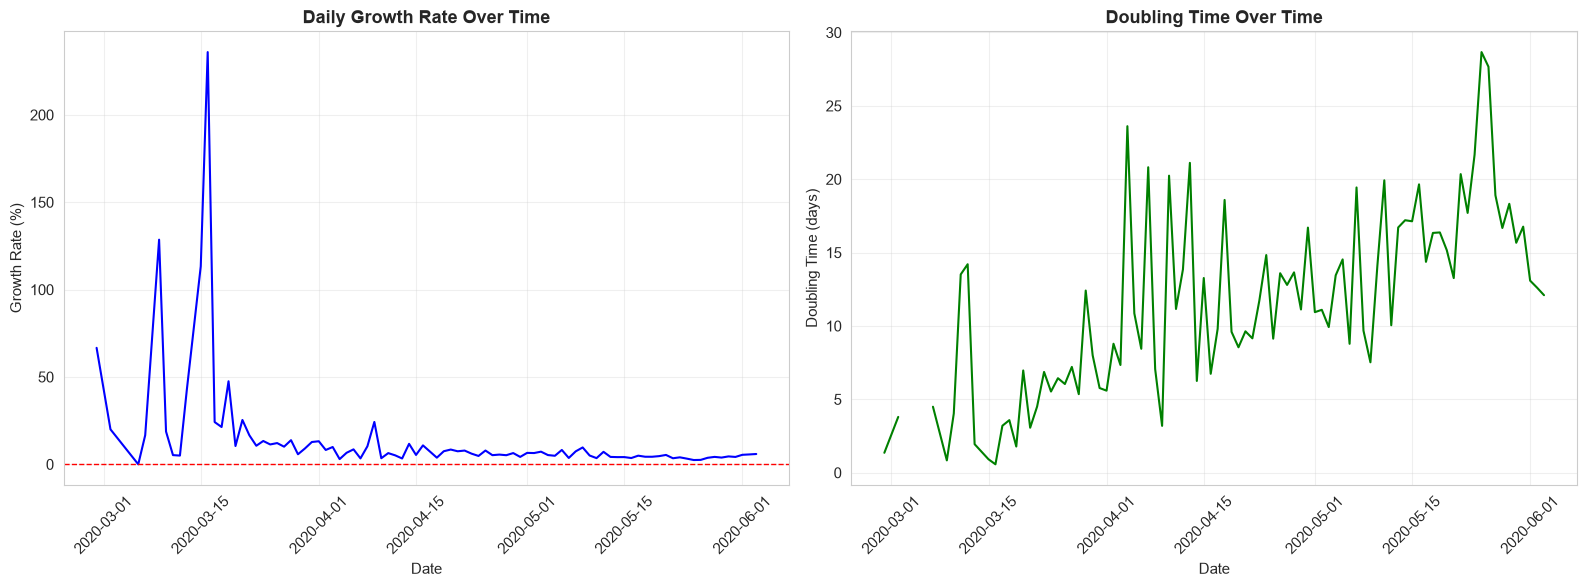

✅ 33_growth_rate.png


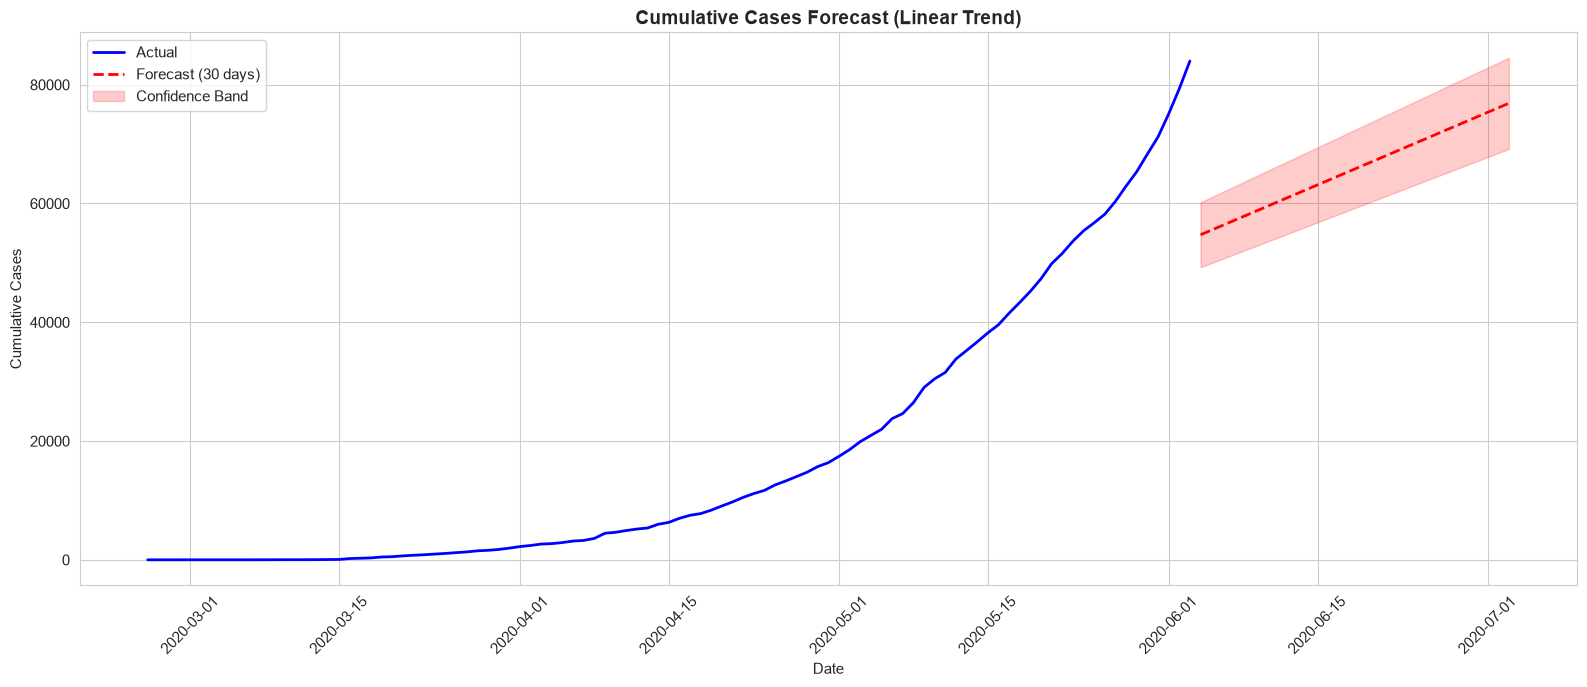

✅ 34_linear_forecast.png

R² Score: 0.7979
Predicted cases after 30 days: 76,879

🎉 Cell 6 Complete!


In [7]:
# ==========================================
# CELL 6: GROWTH RATE ANALYSIS + LINEAR FORECAST
# ==========================================

# ==================== 6.1 Growth Rate ====================
daily['Growth_Rate'] = daily['Cumulative_Cases'].pct_change() * 100
daily['Doubling_Time'] = np.log(2) / np.log(1 + daily['Growth_Rate']/100)

print("=" * 60)
print("GROWTH RATE ANALYSIS")
print("=" * 60)
print(f"Average daily growth rate: {daily['Growth_Rate'].mean():.2f}%")
print(f"Max growth rate:           {daily['Growth_Rate'].max():.2f}%")
print(f"Average doubling time:     {daily['Doubling_Time'].mean():.2f} days")


# Growth rate chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Growth Rate over time
axes[0].plot(daily['Date'], daily['Growth_Rate'], 'b-', linewidth=1.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Daily Growth Rate Over Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Growth Rate (%)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(alpha=0.3)

# Doubling Time
axes[1].plot(daily['Date'], daily['Doubling_Time'], 'g-', linewidth=1.5)
axes[1].set_title('Doubling Time Over Time', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Doubling Time (days)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '33_growth_rate.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 33_growth_rate.png")


# ==================== 6.2 Linear Forecast ====================
daily['Day_Num'] = (daily['Date'] - daily['Date'].min()).dt.days
X_fc = daily['Day_Num'].values.reshape(-1, 1)
y_fc = daily['Cumulative_Cases'].values

model_fc = LinearRegression()
model_fc.fit(X_fc, y_fc)

# Predict next 30 days
future_days = np.arange(X_fc.max() + 1, X_fc.max() + 31).reshape(-1, 1)
future_dates = pd.date_range(daily['Date'].max() + pd.Timedelta(days=1), periods=30)
predictions = model_fc.predict(future_days)

# Plot forecast
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(daily['Date'], daily['Cumulative_Cases'], 'b-', label='Actual', linewidth=2)
ax.plot(future_dates, predictions, 'r--', label='Forecast (30 days)', linewidth=2)
ax.fill_between(future_dates, predictions * 0.9, predictions * 1.1,
                alpha=0.2, color='red', label='Confidence Band')
ax.set_title('Cumulative Cases Forecast (Linear Trend)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Cases')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, '34_linear_forecast.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ 34_linear_forecast.png")

print(f"\nR² Score: {model_fc.score(X_fc, y_fc):.4f}")
print(f"Predicted cases after 30 days: {predictions[-1]:,.0f}")

print("\n🎉 Cell 6 Complete!")

In [8]:
# ==========================================
# CELL 7: 6 INTERACTIVE PLOTLY CHARTS
# ==========================================

import plotly.express as px
import plotly.graph_objects as go

INTERACTIVE_PATH = r'D:\DA projects\Covid-19-portfolio\outputs\interactive'
os.makedirs(INTERACTIVE_PATH, exist_ok=True)

# ==================== 7.1 Interactive Daily Trend ====================
fig = go.Figure()
fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Cases'],
                         mode='lines+markers', name='Cases',
                         line=dict(color='blue', width=2)))
fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Recovered'],
                         mode='lines+markers', name='Recovered',
                         line=dict(color='green', width=2)))
fig.add_trace(go.Scatter(x=daily['Date'], y=daily['Deaths'],
                         mode='lines+markers', name='Deaths',
                         line=dict(color='red', width=2)))
fig.update_layout(title='Pakistan COVID-19 Daily Trend (Interactive)',
                  xaxis_title='Date', yaxis_title='Count',
                  hovermode='x unified', template='plotly_white', height=600)
fig.write_html(os.path.join(INTERACTIVE_PATH, '01_daily_trend.html'))
print("✅ 01_daily_trend.html")


# ==================== 7.2 Interactive Province Bubble ====================
fig = px.scatter(province_summary, x='Cases', y='CFR',
                 size='Deaths', color='Province',
                 hover_name='Province', size_max=60,
                 title='Provincial Analysis: Cases vs CFR (Bubble = Deaths)',
                 labels={'Cases': 'Total Cases', 'CFR': 'CFR (%)'})
fig.update_layout(template='plotly_white', height=600)
fig.write_html(os.path.join(INTERACTIVE_PATH, '02_province_bubble.html'))
print("✅ 02_province_bubble.html")


# ==================== 7.3 Interactive Treemap ====================
fig = px.treemap(df, path=['Province', 'City'], values='Cases',
                 color='Cases', color_continuous_scale='RdYlGn_r',
                 title='COVID-19 Cases Treemap: Province → City')
fig.update_layout(height=700)
fig.write_html(os.path.join(INTERACTIVE_PATH, '03_treemap.html'))
print("✅ 03_treemap.html")


# ==================== 7.4 Interactive Sunburst ====================
fig = px.sunburst(df, path=['Province', 'City'], values='Cases',
                  color='Cases', color_continuous_scale='Blues',
                  title='COVID-19 Cases Sunburst')
fig.update_layout(height=700)
fig.write_html(os.path.join(INTERACTIVE_PATH, '04_sunburst.html'))
print("✅ 04_sunburst.html")


# ==================== 7.5 Interactive Heatmap ====================
fig = px.imshow(pivot_prov_time,
                labels=dict(x="Month", y="Province", color="Cases"),
                title='Interactive Heatmap: Province × Month',
                color_continuous_scale='YlOrRd',
                aspect='auto', text_auto=True)
fig.update_layout(height=600)
fig.write_html(os.path.join(INTERACTIVE_PATH, '05_heatmap.html'))
print("✅ 05_heatmap.html")


# ==================== 7.6 Interactive Animated Bar ====================
daily['Frame'] = daily['Date'].dt.strftime('%Y-%m')
fig = px.bar(daily, x='Date', y='Cases',
             animation_frame='Frame',
             title='Animated Daily Cases',
             color='Cases', color_continuous_scale='Reds')
fig.update_layout(template='plotly_white', height=600)
fig.write_html(os.path.join(INTERACTIVE_PATH, '06_animated.html'))
print("✅ 06_animated.html")

print("\n🎉 Cell 7 Complete — 6 interactive HTML files saved!")

✅ 01_daily_trend.html
✅ 02_province_bubble.html
✅ 03_treemap.html
✅ 04_sunburst.html
✅ 05_heatmap.html
✅ 06_animated.html

🎉 Cell 7 Complete — 6 interactive HTML files saved!
